In [1]:
import polars as pl 
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
headers = "seqID   start   end     sequenceOfArm   sequenceOfSpacer        sequence        armLength       spacerLength    sequenceLength  sequence_length modified_sequence_length        arm_a   arm_g   arm_c    arm_t   composition     Repeated        sru     consensus_repeats".split(" ")
headers = list(filter(len, headers))
headers

['seqID',
 'start',
 'end',
 'sequenceOfArm',
 'sequenceOfSpacer',
 'sequence',
 'armLength',
 'spacerLength',
 'sequenceLength',
 'sequence_length',
 'modified_sequence_length',
 'arm_a',
 'arm_g',
 'arm_c',
 'arm_t',
 'composition',
 'Repeated',
 'sru',
 'consensus_repeats']

# Homo Sapiens

In [3]:
from pathlib import Path

primates = {
            "mPonPyg2": "P. pygmaeus",
            "mPanTro3": "P. troglodytes",
            "mGorGor1": "G. gorilla",
            "chm13v2": "H. sapiens",
            "mPanPan1": "P. paniscus",
            "mPonAbe1": "P. abelii",
            "mSymSyn1": "S. syndactylus",
    }
primates_path = Path("../primates_STR").resolve()
primate_STR = {file.name.split('.')[0]: file for file in primates_path.glob("*.tsv") if file.is_file()}
primate_STR.pop("hg38_STR")
primate_STR

{'mSymSyn1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_STR/mSymSyn1.pri.cur.20240514.fasta_STR.processed.tsv'),
 'mPonAbe1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_STR/mPonAbe1.pri.cur.20231205.fasta_STR.processed.tsv'),
 'mPonPyg2': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_STR/mPonPyg2.pri.cur.20231122.fasta_STR.processed.tsv'),
 'mGorGor1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_STR/mGorGor1.pri.cur.20231122.fasta_STR.processed.tsv'),
 'chm13v2_STR_head': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_STR/chm13v2_STR_head.tsv'),
 'mPanTro3': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_STR/mPanTro3.pri.cur.20231122.fasta_STR.processed.tsv'),
 'chm13v2': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_STR/chm13v2.0_STR.processed.tsv'),
 'mPanPan1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_STR/mPanPan1.pri.cur.20231122.fasta_STR.processed.tsv')}

In [4]:
from pybedtools import BedTool
df = pd.read_table("../compartments_T2T_coding_protein_coding.ZDNA.csv.gz")
df_bed = BedTool.from_dataframe(df).sort()
df_bed

<BedTool(/tmp/pybedtools.z5vvi7la.tmp)>

In [5]:
df["comp"].unique()

array(['Telomere', 'Non Coding Exons', 'Non Coding Genes',
       'Non Coding Promoters', 'Enhancer', 'CDS', 'Protein Coding Exons',
       'Protein Coding Genes', 'Protein Coding Promoters', 'Silencer',
       'five_prime_UTR', 'three_prime_UTR', 'ct', 'censat', 'hor', 'dhor',
       'hsat2', 'hsat3', 'gsat', 'bsat', 'mon', 'hsat1B', 'hsat1A',
       'rDNA'], dtype=object)

In [41]:
COVERAGE_FIELDS = ["totalHits", "overlappingBp", "compartmentLength", "coverage"]
chm13v2_df = pd.read_table(primate_STR["chm13v2"],
                           # header=None, 
                           # names=headers
                          )
chm13v2_df = chm13v2_df[chm13v2_df["sequence_length"] >= 10].reset_index(drop=True)
chm13v2_bed = BedTool.from_dataframe(chm13v2_df[["seqID", "start", "end", "sru"]]).sort().merge()
coverage = pd.read_table(
    df_bed.coverage(chm13v2_bed).fn,
    header=None,
    names=list(df.columns) + COVERAGE_FIELDS
)
coverage.loc[:, "STR_density"] = 1e3 * coverage["overlappingBp"] / coverage["compartmentLength"]
coverage_agg = coverage.groupby("comp", as_index=False)\
                .agg(
                        STR_density=("STR_density", "mean")
                )\
                .sort_values(by=["STR_density"], ascending=False)\
                .reset_index(drop=True)
coverage_agg

,comp,STR_density
0,Telomere,852.556318
1,hsat3,207.593362
2,rDNA,109.592024
3,gsat,27.800177
4,hsat1B,25.065440
5,censat,23.372673
6,hsat2,22.529688
7,Non Coding Promoters,17.512712
8,Protein Coding Promoters,15.280506
9,Silencer,15.257376


In [42]:
coverage["comp"] = coverage["comp"].replace("five_prime_UTR", "5' UTR").replace("three_prime_UTR", "3' UTR")
coverage_agg_seqID = coverage.groupby(["comp", "seqID"], as_index=False)\
                .agg(
                        STR_density=("STR_density", "mean")
                )\
                .sort_values(by=["STR_density"], ascending=False)\
                .reset_index(drop=True)
df_coverage_piv_all = coverage_agg_seqID.pivot(index="seqID", columns="comp", values="STR_density").fillna(0.0)
df_coverage_piv_all

comp,3' UTR,5' UTR,CDS,Enhancer,Non Coding Exons,Non Coding Genes,Non Coding Promoters,Protein Coding Exons,Protein Coding Genes,Protein Coding Promoters,...,ct,dhor,gsat,hor,hsat1A,hsat1B,hsat2,hsat3,mon,rDNA
seqID,,,,,,,,,,,,,,,,,,,,,
chr1,7.885254,7.201384,2.170601,9.826253,4.552936,9.873419,18.460215,3.737765,13.518951,15.229288,...,14.774999,1.479940,43.966324,0.113089,0.000000,0.000000,17.829861,289.035924,0.000000,0.000000
chr10,7.132871,7.556184,1.834744,10.961962,4.093329,11.309675,16.871603,3.628422,13.778366,14.325107,...,11.807644,0.000000,0.000000,0.013086,0.000000,0.000000,17.783799,237.148112,1.762730,0.000000
chr11,7.336597,6.513345,2.575997,8.747141,3.838187,10.381360,14.280603,3.847545,11.945310,12.981176,...,19.216299,0.000000,0.000000,0.007018,0.000000,0.000000,0.000000,0.000000,3.668188,0.000000
chr12,9.061276,7.326231,2.194235,10.752351,4.151967,11.724585,14.907239,3.869622,14.516355,15.816259,...,14.587881,0.651391,2.211422,0.026830,0.000000,0.000000,0.000000,0.000000,4.640959,0.000000
chr13,7.410037,6.077690,1.974261,9.532012,6.823016,18.792232,31.908476,3.354497,12.736722,15.625980,...,13.317510,0.000000,34.757426,0.000000,1.801196,45.875850,0.000000,244.774904,1.873978,119.885629
chr14,6.762917,7.278759,2.496061,9.927378,4.246687,8.409018,15.286707,3.985433,13.641937,12.338331,...,12.188442,0.535231,46.287974,0.181764,3.426993,35.413149,0.000000,245.382401,1.644882,107.887798
chr15,7.588625,6.363956,2.194868,10.796124,4.992852,12.778430,21.376941,3.435445,14.718737,16.389107,...,13.601811,2.092926,42.721477,0.000000,2.285952,22.369526,0.000000,225.859361,2.061546,106.435903
chr16,12.317595,9.280616,2.617437,11.430087,4.081483,12.493464,17.034120,4.489374,15.160470,15.722120,...,13.558513,0.814349,0.000000,0.004983,0.000000,0.000000,18.044981,255.181038,3.798222,0.000000
chr17,8.470187,6.700153,2.282162,11.088318,4.100865,11.555360,17.613863,3.626489,14.857341,15.871836,...,10.759544,0.000000,0.000000,0.012567,0.000000,0.000000,15.198014,196.277537,5.299816,0.000000


In [43]:
df_coverage_piv_all["Enhancer"]

seqID
chr1      9.826253
chr10    10.961962
chr11     8.747141
chr12    10.752351
chr13     9.532012
chr14     9.927378
chr15    10.796124
chr16    11.430087
chr17    11.088318
chr18    10.284425
chr19    12.611202
chr2     10.806647
chr20    10.292836
chr21    10.199358
chr22    11.706841
chr3      9.682072
chr4     11.785588
chr5      9.586204
chr6      9.349117
chr7     10.659015
chr8     10.486872
chr9      9.211035
chrX      9.832071
chrY     50.891358
Name: Enhancer, dtype: float64

In [44]:
gw_STR_density = pd.read_table(
                chm13v2_bed.merge().fn,
                header=None,
                names=["seqID", "start", "end"]
).assign(length=lambda ds: ds["end"] - ds["start"])
gw_STR_density = gw_STR_density["length"].sum()
gw_STR_density  

np.int64(61886601)

In [45]:
genome_sizes = pl.read_csv("primate_genome_sizes.tsv", 
                           separator="\t", has_header=False, new_columns=["species", "genome_size"])
genome_sizes = dict(zip(genome_sizes["species"], genome_sizes["genome_size"]))
genome_sizes

{'G. gorilla': 3545834224,
 'P. paniscus': 3244888708,
 'H. sapiens': 3117292070,
 'S. syndactylus': 3262887708,
 'P. abelii': 3259853530,
 'P. pygmaeus': 3220935163,
 'P. troglodytes': 3177739762}

In [46]:
gw_STR_density  = gw_STR_density * 1e3 / float(genome_sizes["H. sapiens"])
gw_STR_density

np.float64(19.85267970094313)

In [47]:
coverage_df = pd.concat([
    coverage[["STR_density", "comp"]],
    pd.DataFrame({"STR_density": [gw_STR_density], "comp": ["Genome-wide"]})
])

coverage_agg = coverage_df.groupby("comp", as_index=False)\
                .agg(
                        STR_density=("STR_density", "mean")
                )\
                .sort_values(by=["STR_density"], ascending=False)\
                .reset_index(drop=True)
coverage_df

,STR_density,comp
0,851.666667,Telomere
1,4.747124,Non Coding Exons
2,10.391296,Non Coding Genes
3,0.000000,Non Coding Exons
4,0.000000,Non Coding Exons
...,...,...
891933,0.000000,Non Coding Exons
891934,0.000000,Non Coding Promoters
891935,9.111617,censat
891936,953.443570,Telomere


In [48]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['ps.fonttype'] = 42

target = Path("../STR_figures/primates_STR")
target.mkdir(exist_ok=True, parents=True)

../figures/primate_figures


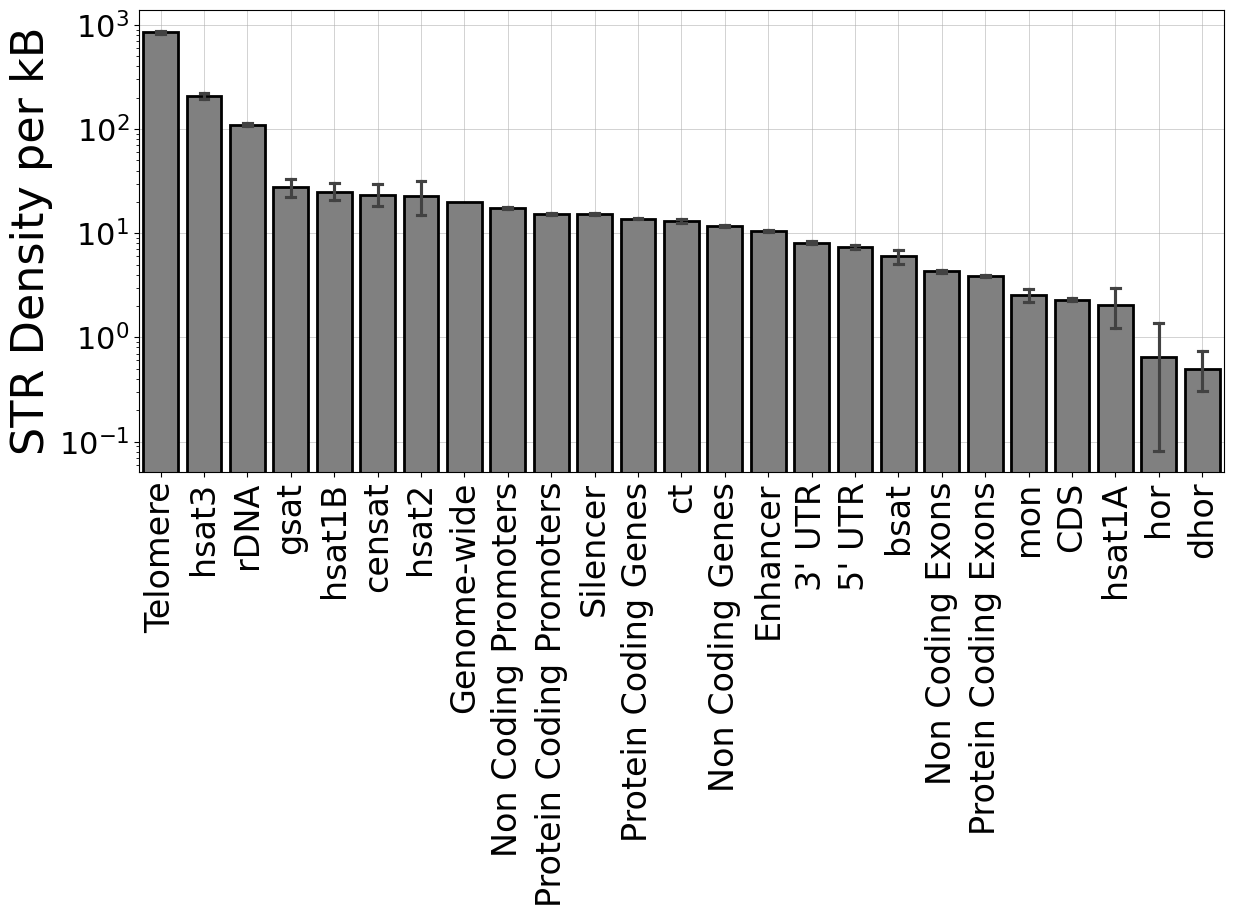

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  
mpl.rcParams['ps.fonttype'] = 42  
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 6))
coverage_df["comp"] = coverage_df["comp"].replace("five_prime_UTR", "5' UTR").replace("three_prime_UTR", "3' UTR")
coverage_agg["comp"] = coverage_agg["comp"].replace("five_prime_UTR", "5' UTR").replace("three_prime_UTR", "3' UTR")
order = coverage_agg["comp"].tolist()
sns.barplot(
            data=coverage_df,
            x="comp",
            y="STR_density",
            ax=ax,
            saturation=0.2,
            edgecolor="black",
            capsize=.2,
            linewidth=2.0,
            color="gray",
            order=order
           )
ax.set_xlabel("")
ax.set_ylabel("STR Density per kB")
ax.yaxis.label.set_size(32)
ax.xaxis.label.set_size(18)
ax.tick_params(axis="both", labelsize=24)
ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="y", labelsize=22)
ax.grid(lw=0.4)
ax.set_axisbelow(True)
ax.set_yscale("log")
print(target)
# ax.axhline(gw_STR_density, linestyle="--", color="crimson", lw=2.0, transform=ax.transData)
fig.savefig(f"{target}/homo_sapiens_STR_compartment_density.pdf", bbox_inches="tight", dpi=300, transparent=True)

In [50]:
from tqdm import tqdm

MIN_LENGTH_CUTOFF = 10

COVERAGE_FIELDS = ["totalHits", "overlappingBp", "compartmentLength", "coverage"]
chm13v2_df = pd.read_table(primate_STR["chm13v2"], 
                           # header=None, 
                           # names=headers
                          )
chm13v2_df = chm13v2_df[chm13v2_df["sequence_length"] >= MIN_LENGTH_CUTOFF]
df_coverage = []
sru_list = list(range(1, 10))
for sru in tqdm(range(1, 10)):
    if sru != "all":
        chm13v2_bed = BedTool.from_dataframe(chm13v2_df.query(f"sru == {sru}")[["seqID", "start", "end", "sru"]]).sort().merge()
    else:
        chm13v2_bed = BedTool.from_dataframe(chm13v2_df[["seqID", "start", "end", "sru"]]).sort().merge()
    coverage = pd.read_table(
        df_bed.coverage(chm13v2_bed).fn,
        header=None,
        names=list(df.columns) + COVERAGE_FIELDS
        )
    coverage.loc[:, "STR_density"] = 1e3 * coverage["overlappingBp"] / coverage["compartmentLength"]
    coverage = coverage.groupby(["seqID", "comp"], as_index=False)\
                        .agg(
                            STR_density=("STR_density", "mean")
                        ).assign(sru=sru)
    df_coverage.append(coverage)
df_coverage = pd.concat(df_coverage, ignore_index=True)
df_coverage["comp"] = df_coverage["comp"].replace("five_prime_UTR", "5' UTR").replace("three_prime_UTR", "3' UTR")
df_coverage

100%|██████████| 9/9 [00:36<00:00,  4.08s/it]


,seqID,comp,STR_density,sru
0,chr1,CDS,0.068880,1
1,chr1,Enhancer,3.352573,1
2,chr1,Non Coding Exons,0.912427,1
3,chr1,Non Coding Genes,3.685342,1
4,chr1,Non Coding Promoters,5.319474,1
...,...,...,...,...
4324,chrY,hor,0.000000,9
4325,chrY,hsat1B,0.000000,9
4326,chrY,hsat3,0.000000,9
4327,chrY,mon,0.000000,9


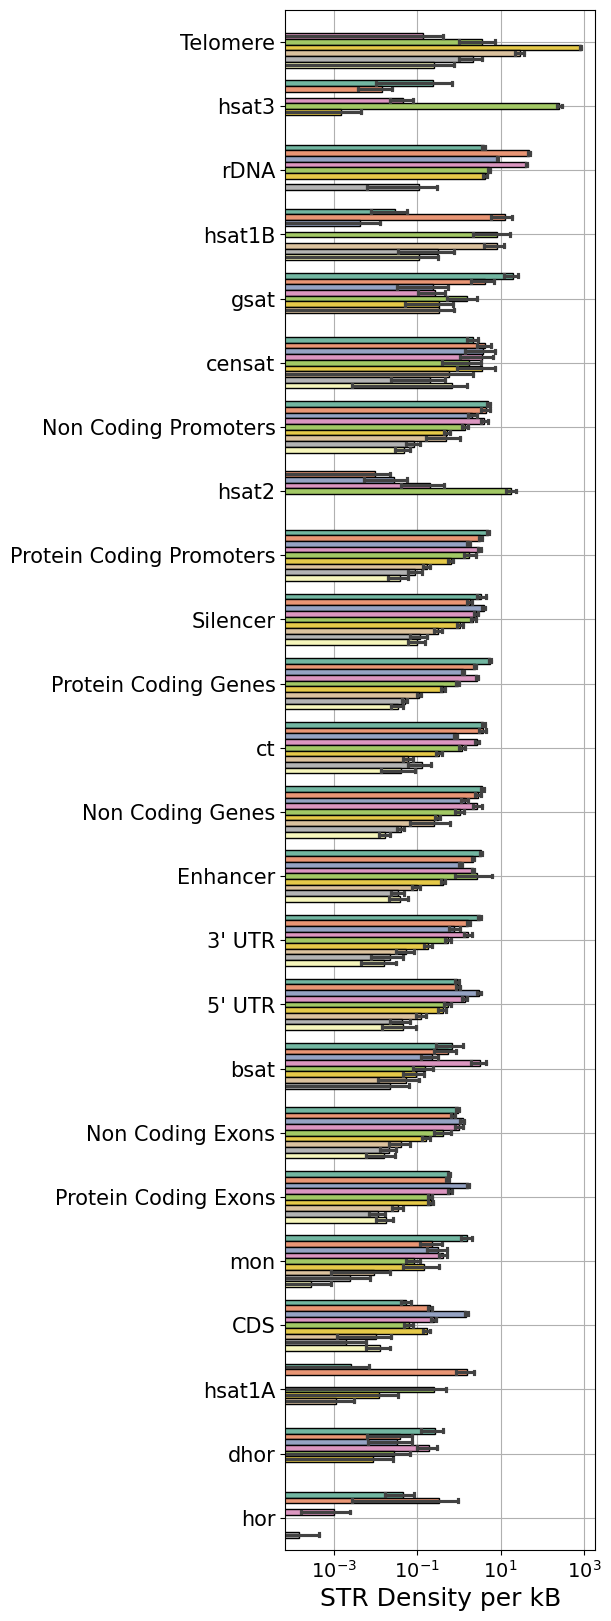

In [38]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 20))

order  = list(df_coverage.groupby("comp").agg(density=("STR_density", "mean")).sort_values(by=["density"],ascending=False).index)
sns.barplot(data=df_coverage, ax=ax, y="comp", x="STR_density", hue="sru",
            edgecolor='black',
            orient="h",
            hue_order=list(range(1, 10)),
            dodge=True,
            width=0.8,
            capsize=0.4,
            # saturation=0.8,
            order=order,
            palette=sns.color_palette("Set2") + sns.color_palette("Set3")[1:2],
            linewidth=1.0)
ax.grid()
ax.legend(handles=[], frameon=False)
ax.set_axisbelow(True)
ax.set_xlabel("STR Density per kB")
ax.xaxis.label.set_size(18)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=15)
ax.set_xscale("log")
fig.savefig(f"{target}/sru_STR_compartment_density_breakdown.pdf", transparent=True, bbox_inches='tight')

In [61]:
df_coverage_piv

comp,3' UTR,5' UTR,CDS,Enhancer,Non Coding Exons,Non Coding Genes,Non Coding Promoters,Protein Coding Exons,Protein Coding Genes,Protein Coding Promoters,...,ct,dhor,gsat,hor,hsat1A,hsat1B,hsat2,hsat3,mon,rDNA
seqID,,,,,,,,,,,,,,,,,,,,,
chr1,0.896816,0.857416,0.336580,0.992388,0.658292,0.994468,1.266237,0.572612,1.130943,1.182680,...,14.774999,1.479940,43.966324,0.113089,0.000000,0.000000,17.829861,289.035924,0.000000,0.000000
chr10,0.853264,0.878303,0.263575,1.039888,0.612077,1.053450,1.227156,0.559718,1.139198,1.156098,...,11.807644,0.000000,0.000000,0.013086,0.000000,0.000000,17.783799,237.148112,1.762730,0.000000
chr11,0.865495,0.813804,0.410945,0.941866,0.584126,1.016254,1.154747,0.585184,1.077197,1.113314,...,19.216299,0.000000,0.000000,0.007018,0.000000,0.000000,0.000000,0.000000,3.668188,0.000000
chr12,0.957189,0.864881,0.341283,1.031503,0.618254,1.069097,1.173397,0.587669,1.161858,1.199104,...,14.587881,0.651391,2.211422,0.026830,0.000000,0.000000,0.000000,0.000000,4.640959,0.000000
chr13,0.869820,0.783739,0.295405,0.979185,0.833976,1.273978,1.503906,0.525627,1.105058,1.193847,...,13.317510,0.000000,34.757426,0.000000,1.801196,45.875850,0.000000,244.774904,1.873978,119.885629
chr14,0.830134,0.862057,0.397255,0.996835,0.628050,0.924745,1.184314,0.600475,1.134876,1.091256,...,12.188442,0.535231,46.287974,0.181764,3.426993,35.413149,0.000000,245.382401,1.644882,107.887798
chr15,0.880163,0.803727,0.341408,1.033268,0.698349,1.106478,1.329946,0.535983,1.167871,1.214555,...,13.601811,2.092926,42.721477,0.000000,2.285952,22.369526,0.000000,225.859361,2.061546,106.435903
chr16,1.090526,0.967577,0.417876,1.058050,0.610818,1.096683,1.231320,0.652186,1.180713,1.196511,...,13.558513,0.814349,0.000000,0.004983,0.000000,0.000000,18.044981,255.181038,3.798222,0.000000
chr17,0.927893,0.826085,0.358347,1.044866,0.612876,1.062783,1.245855,0.559486,1.171941,1.200627,...,10.759544,0.000000,0.000000,0.012567,0.000000,0.000000,15.198014,196.277537,5.299816,0.000000


all


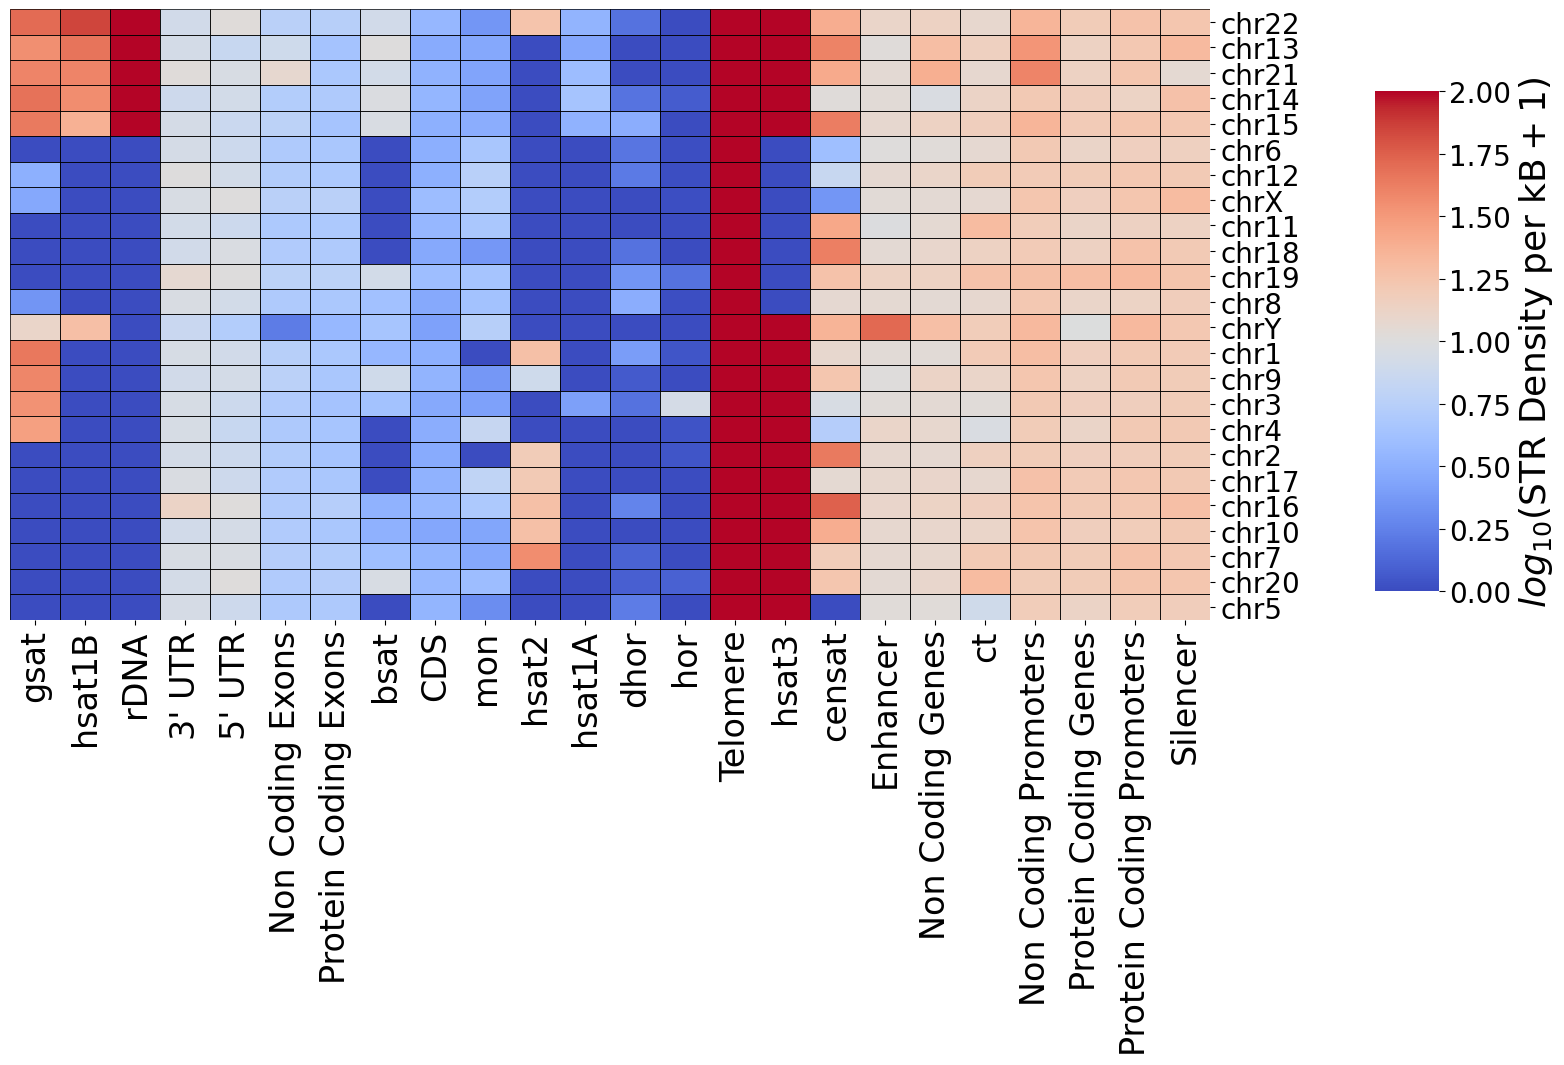

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import math

figsize = (16, 10)
sru_list = list(range(1, 10)) + ["all"]
sru_list = ["all"]
# sru_list = ["all"]
for sru in sru_list:
    print(sru)
    if sru != "all":
        df_coverage_piv = df_coverage.query(f"sru == {sru}")\
                        .pivot(index="seqID", 
                               columns="comp", 
                               values="STR_density").fillna(0.0)
    else:
        df_coverage_piv = df_coverage_piv_all.fillna(0.0)
        for col in df_coverage_piv:
            df_coverage_piv[col] = df_coverage_piv[col].apply(lambda x: math.log(x+1, 10))
    cg = sns.clustermap(
              data=df_coverage_piv,
               row_cluster=True, 
               col_cluster=True,
                method="ward",
                vmax=2.0,
                # vmax=1.0,
                cmap="coolwarm",
               figsize=figsize,
               robust=True,
               yticklabels=True, 
               xticklabels=True,
               cbar_kws={"shrink": 0.1, 
                         "orientation": "vertical"}
               )
    ax = cg.ax_heatmap
    cg.ax_row_dendrogram.set_visible(False)
    cg.ax_col_dendrogram.set_visible(False)
    ax = cg.ax_heatmap
    ax.set_xlabel("", size=24)
    ax.set_ylabel("")
    t = ax.xaxis.get_majorticklocs()
    ax.xaxis.label.set_size(24)
    ax.yaxis.label.set_size(24)
    ax.tick_params(axis="both", which="major", labelsize=20, rotation=0)
    ax.tick_params(axis="x", labelsize=24, rotation=90)
    x0, _y0, _w, _h = cg.cbar_pos
    cg.ax_cbar.set_position([1.05, 0.25, 0.04, 0.5])
    if sru == "all":
        cg.cax.set_ylabel(r'$log_{10}(\mathrm{STR\ Density\ per\ kB + 1})$', size=26) #, labelpad=15, size=12)
    else:
        cg.cax.set_ylabel('STR Density per kB', size=24) #, labelpad=15, size=12)
    cg.ax_cbar.tick_params(axis='both', length=4, labelsize=20)
    cg.ax_cbar.tick_params(axis="x", rotation=90)
    for spine in cg.ax_cbar.spines:
        cg.ax_cbar.spines[spine].set_color('black')
        # cg.ax_cbar.spines[spine].set_linewidth(2)
    
    data = df_coverage_piv.iloc[cg.dendrogram_row.reordered_ind]
    n_rows, n_cols = data.shape
    for i in range(n_rows):
        for j in range(n_cols):
            rect = patches.Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='black', facecolor='none')
            ax.add_patch(rect)
    
    dest = Path("../STR_figures/primates_STR").resolve()
    dest.mkdir(exist_ok=True)
    fig = plt.gcf()
    fig.savefig(target.joinpath(f"STR_clustermap_SRU_human_{sru}.pdf"), 
                dpi=300, 
                transparent=True,
                format="pdf", 
                bbox_inches='tight')
    plt.show()

## Primates

In [14]:
import pandas as pd

In [15]:
primate_STR.pop("chm13v2_STR_head")

PosixPath('/home/dollzeta/biolab/STR_RTR/primates_STR/chm13v2_STR_head.tsv')

In [16]:
from tqdm import tqdm
STR_df = []
MIN_LENGTH_CUTOFF = 10
for primate, file in tqdm(primate_STR.items()):
    df = pl.read_csv(file, 
                          separator="\t", 
                          # has_header=False, 
                          # new_columns=headers
                    )\
                .with_columns(pl.lit(primates[primate]).alias("species"))\
                .filter(pl.col("sequence_length") >= MIN_LENGTH_CUTOFF)
    STR_df.append(df)
                              
STR_df = pl.concat(STR_df)
STR_df

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:04<00:00,  1.66it/s]


seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,sru,consensus_repeats,#assembly_accession,species
str,i64,i64,str,i64,str,i64,str,i64,i64,i64,str,str
"""chr1_hap1""",52,334,"""acccta""",6,""".""",0,"""accctaaccctaaccctaaccctaacccta…",282,6,47,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus"""
"""chr1_hap1""",336,4128,"""ccctaa""",6,""".""",0,"""ccctaaccctaaccctaaccctaaccctaa…",3792,6,632,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus"""
"""chr1_hap1""",4128,11292,"""cctaac""",6,""".""",0,"""cctaaccctaaccctaaccctaaccctaac…",7164,6,1194,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus"""
"""chr1_hap1""",11293,12967,"""ccctaa""",6,""".""",0,"""ccctaaccctaaccctaaccctaaccctaa…",1674,6,279,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus"""
"""chr1_hap1""",12968,13094,"""ccctaa""",6,""".""",0,"""ccctaaccctaaccctaaccctaaccctaa…",126,6,21,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr1522_pat_hsa1421_random_uti…",145978,145998,"""tctg""",4,""".""",0,"""tctgtctgtctgtctgtctg""",20,4,5,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus"""
"""chr1522_pat_hsa1421_random_uti…",146048,146096,"""ca""",2,""".""",0,"""cacacacacacacacacacacacacacaca…",48,2,24,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus"""
"""chr1522_pat_hsa1421_random_uti…",150612,150640,"""ttcc""",4,""".""",0,"""ttccttccttccttccttccttccttcc""",28,4,7,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus"""


In [42]:
STR_df.group_by("species").agg(sequence_length=pl.col("sequence_length").max())

species,sequence_length
str,i64
"""P. troglodytes""",10764
"""H. sapiens""",3228
"""P. abelii""",9174
"""S. syndactylus""",11466
"""P. paniscus""",9462
"""G. gorilla""",8292
"""P. pygmaeus""",9042


In [17]:
seqID_counts = df.group_by(["species", "seqID"]).agg(total_tandem=pl.col("start").count())
seqID_counts

species,seqID,total_tandem
str,str,u32
"""P. paniscus""","""chr12_mat_hsa2a""",148566
"""P. paniscus""","""chr10_mat_hsa12""",124383
"""P. paniscus""","""chr23_pat_hsa22""",246578
"""P. paniscus""","""chr5_pat_hsa6""",149847
"""P. paniscus""","""chr7_pat_hsa8""",128172
…,…,…
"""P. paniscus""","""chr1522_pat_hsa1421_random_uti…",66
"""P. paniscus""","""chr8_mat_hsa10""",126415
"""P. paniscus""","""chr14_pat_hsa13""",94609


In [44]:
# import matplotlib.pyplot as plt
# import seaborn as sns 

# for species in seqID_counts["species"].unique():
#     STR_df_temp = seqID_counts.filter(pl.col('species') == species)
#     fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))
#     sns.barplot(data=STR_df_temp,
#                 y="total_tandem",
#                 ax=ax,
#                 x="seqID")
#     ax.set_xlabel("")
#     ax.set_title(species)
#     ax.title.set_size(18)
#     ax.tick_params(axis="x", rotation=90)
#     plt.show()

In [ ]:
MIN_LENGTH_CUTOFF = 10
STR_df = STR_df.with_columns(
    admissible=pl.col("sequence_length").map_elements(lambda x: int(x >= MIN_LENGTH_CUTOFF), return_dtype=pl.Int64)
)
STR_df.head()

In [ ]:
STR_df["admissible"].value_counts()

admissible,count
i64,u32
1,26162108
0,3229832


In [18]:

STR_motifs = (
    STR_df.select(["species", "sru", "arm_length"])
                                                .filter(pl.col("sru") <= 6)
                                                .group_by(["species", "sru"])
                                .agg(
                                        total_STR=pl.col("arm_length").count()
                        )
)
STR_motif_perc_gain = (
        STR_df.select(["species", "sru", "arm_length", "admissible"])
                        .filter(pl.col("sru") <= 6)
                        .group_by(["species", "sru", "admissible"])
        .agg(
                total_STR_perc=pl.col("arm_length").count()
        )
        .join(
                STR_motifs,
                on=["species", "sru"],
                how="left"
        )
        .with_columns(
            STR_perc=pl.col("total_STR_perc") / pl.col("total_STR") * 100
        )
).filter(pl.col("sru") == 3)
STR_motif_perc_gain

ColumnNotFoundError: admissible

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["seqID", "start", "end", "sequence_of_arm", ...]; PROJECT */13 COLUMNS

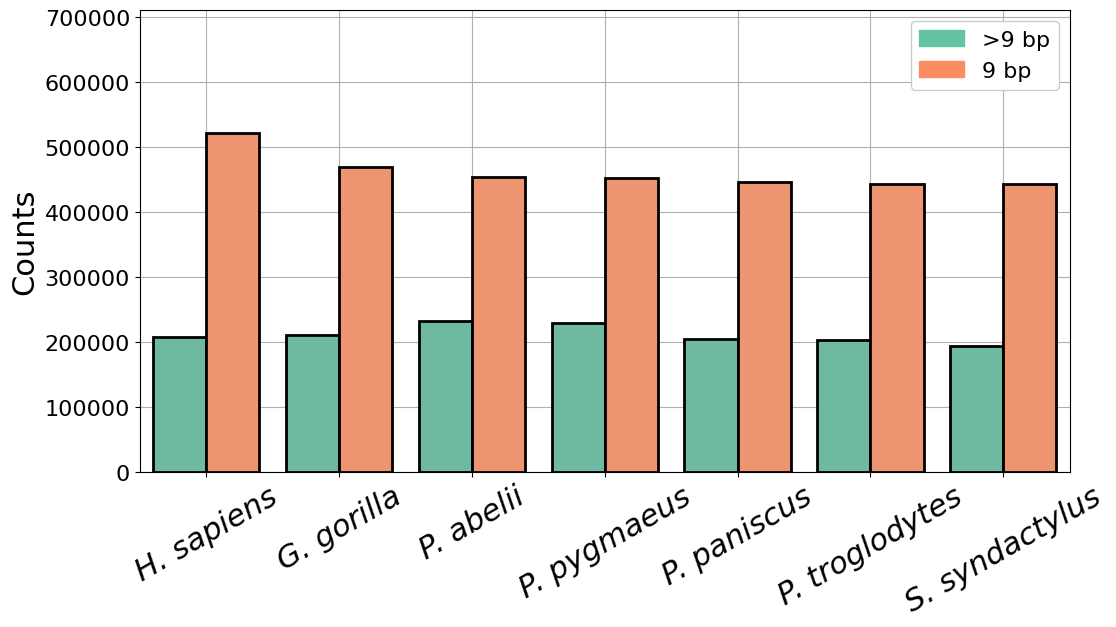

In [107]:
from matplotlib import patches as mpatches 
trinucleotide_repeats = STR_motif_perc_gain.pivot(index=["species"], 
                          on=["admissible"], 
                          values="total_STR_perc").fill_null(0.0)
trinucleotide_repeats = trinucleotide_repeats.to_pandas().reset_index().melt(id_vars=["species"], var_name="admissible").query("admissible != 'index'")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
sns.barplot(data=trinucleotide_repeats,
            x="species",
            y="value",
            palette={"1": sns.color_palette("Set2")[0], 
                     "0": sns.color_palette("Set2")[1]},
            linewidth=2.0,
            edgecolor='black',
            hue="admissible",
            saturation=0.8,
            hue_order=["1", "0"],
            order=["H. sapiens", "G. gorilla", "P. abelii", "P. pygmaeus", "P. paniscus", "P. troglodytes", "S. syndactylus"],
            ax=ax)
ax.grid()
ax.legend(title="", handles=[mpatches.Patch(color=sns.color_palette("Set2")[0], label='>9 bp'),
                             mpatches.Patch(color=sns.color_palette("Set2")[1], label='9 bp')],
                             fancybox=True, framealpha=1,
          loc='upper right', fontsize=16)
ax.set_axisbelow(True)
ax.set_ylabel("Counts")
ymax = ax.set_ylim()[1]
ax.set_ylim(ymax=ymax + ymax*0.3)
ax.set_xlabel("")
ax.yaxis.label.set_size(22)
ax.tick_params(axis="both", labelsize=16)
ax.tick_params(axis="x", rotation=30, labelsize=22)
for label in ax.get_xticklabels():
    label.set_style('italic')

fig.savefig(f"{target}/primates_trinucleotide_STR_counts.pdf", bbox_inches="tight", dpi=300, transparent=True)

In [13]:
STR_df = STR_df.filter(pl.col("sequence_length") >= 10)
STR_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,sru,consensus_repeats,#assembly_accession,species,admissible
str,i64,i64,str,i64,str,i64,str,i64,i64,i64,str,str,i64
"""chr1_hap1""",52,334,"""acccta""",6,""".""",0,"""accctaaccctaaccctaaccctaacccta…",282,6,47,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus""",1
"""chr1_hap1""",336,4128,"""ccctaa""",6,""".""",0,"""ccctaaccctaaccctaaccctaaccctaa…",3792,6,632,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus""",1
"""chr1_hap1""",4128,11292,"""cctaac""",6,""".""",0,"""cctaaccctaaccctaaccctaaccctaac…",7164,6,1194,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus""",1
"""chr1_hap1""",11293,12967,"""ccctaa""",6,""".""",0,"""ccctaaccctaaccctaaccctaaccctaa…",1674,6,279,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus""",1
"""chr1_hap1""",12968,13094,"""ccctaa""",6,""".""",0,"""ccctaaccctaaccctaaccctaaccctaa…",126,6,21,"""mSymSyn1.pri.cur.20240514.fast…","""S. syndactylus""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr1522_pat_hsa1421_random_uti…",145978,145998,"""tctg""",4,""".""",0,"""tctgtctgtctgtctgtctg""",20,4,5,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus""",1
"""chr1522_pat_hsa1421_random_uti…",146048,146096,"""ca""",2,""".""",0,"""cacacacacacacacacacacacacacaca…",48,2,24,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus""",1
"""chr1522_pat_hsa1421_random_uti…",150612,150640,"""ttcc""",4,""".""",0,"""ttccttccttccttccttccttccttcc""",28,4,7,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus""",1


In [19]:
STR_motifs = (
    STR_df.select(["species", "sru", "arm_length"])
                                                .filter(pl.col("sru") <= 6)
                                                .group_by("species")
                                .agg(
                                        total_STR=pl.col("arm_length").count()
                        )
)
STR_motif_perc = (
        STR_df.select(["species", "sru", "arm_length"])
                        .filter(pl.col("sru") <= 6)
                        .group_by(["species", "sru"])
        .agg(
                total_STR_perc=pl.col("arm_length").count()
        )
        .join(
                STR_motifs,
                on="species",
                how="left"
        )
        .with_columns(
            STR_perc=pl.col("total_STR_perc") / pl.col("total_STR") * 100
        )
)
STR_motif_perc

species,sru,total_STR_perc,total_STR,STR_perc
str,i64,u32,u32,f64
"""P. paniscus""",1,1002692,3903877,25.684518
"""G. gorilla""",4,600899,5129328,11.714965
"""S. syndactylus""",4,575989,2771437,20.783045
"""P. abelii""",2,633169,3688276,17.167072
"""P. pygmaeus""",6,59350,3726031,1.592848
…,…,…,…,…
"""P. abelii""",1,1045576,3688276,28.348638
"""S. syndactylus""",2,584141,2771437,21.077188
"""H. sapiens""",4,611285,3614089,16.913944


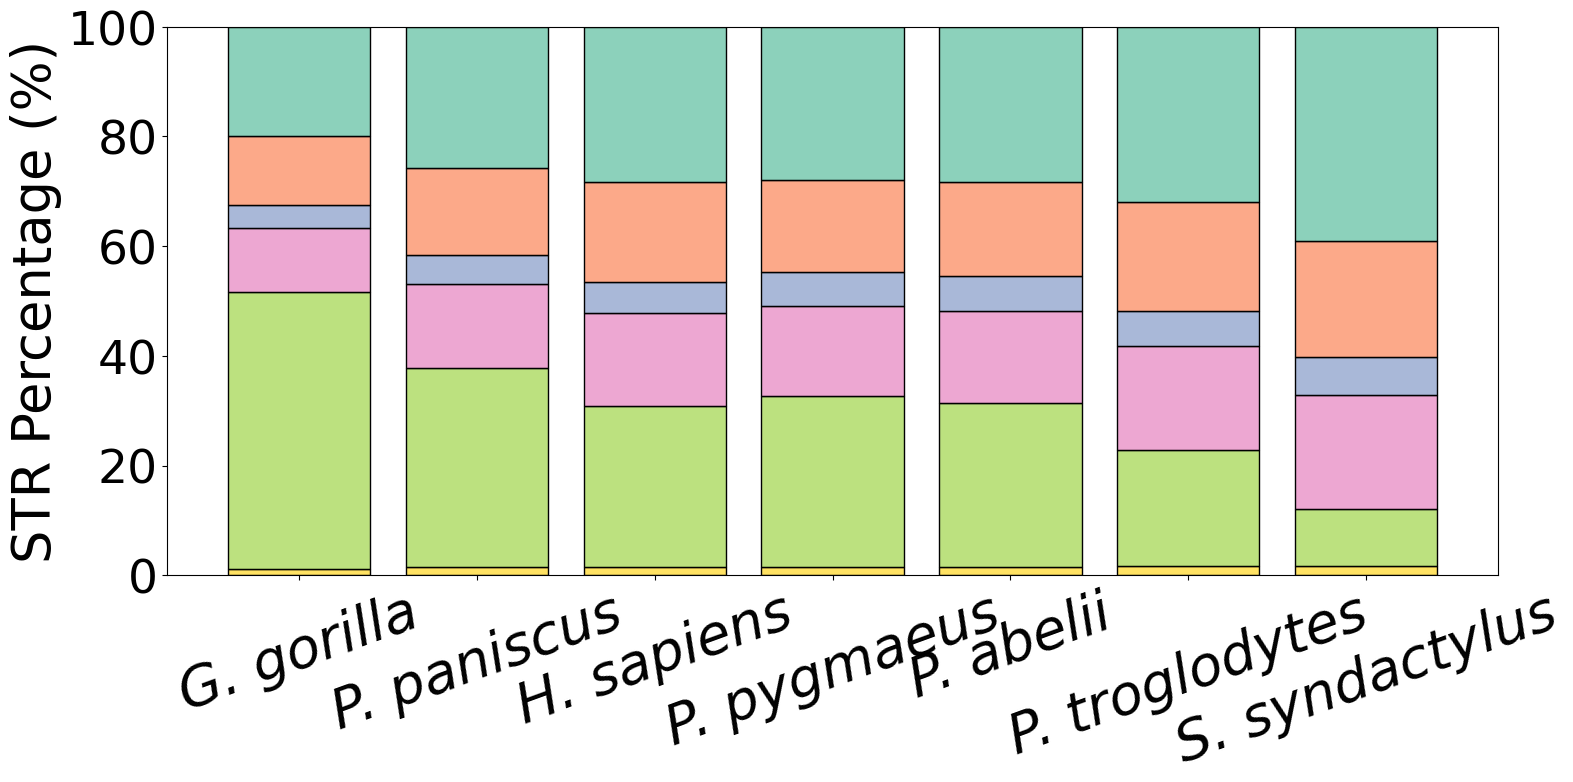

In [ ]:
from matplotlib import patches as mpatches

# Alternative approach using seaborn histplot with kind="bar" for stacked bars
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 8))

# Create stacked barplot using seaborn histplot with kind="bar"

order=["G. gorilla",
           "P. paniscus",
           "H. sapiens",
           "P. pygmaeus",
           "P. abelii",
           "P. troglodytes",
           "S. syndactylus"]

# STR_motif_perc = STR_motif_perc.sort(by=["species"], descending=False)
STR_motif_perc_pd = STR_motif_perc.to_pandas()
STR_motif_perc_pd["species"] = pd.Categorical(
    STR_motif_perc_pd["species"],
    categories=order,
    ordered=True
)
STR_motif_perc_pd["sru"] = pd.Categorical(
    STR_motif_perc_pd["sru"],
    categories=list(range(1, 7)),
    ordered=True
)

sns.histplot(
    data=STR_motif_perc_pd, 
    x="species", 
    hue="sru",
    weights="STR_perc",
    multiple="stack",
    shrink=0.8,
    ax=ax,
    palette="Set2"
)

plt.xlabel('Species', fontsize=12)
plt.ylabel('STR Percentage (%)', fontsize=26)
ax.yaxis.label.set_size(44)
ax.tick_params(axis="y", labelsize=34)
ax.tick_params(axis="x", labelsize=40, rotation=20)
handles = [mpatches.Patch(color=color, label=f"{sru}") for sru, color in zip(range(1, 7), sns.color_palette("Set2", n_colors=6))]6)
# ax.legend(title="", handles=handles, fancybox=True, shadow=True, prop={"size": 20}, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.legend(handles=[], frameon=False)
# plt.legend(title='STR Motif (SRU)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax.set_xlabel("")
ax.set_ylim(ymax=100.0)
for label in ax.get_xticklabels():
    label.set_style('italic')
target = Path("../STR_figures/primates_STR").resolve()
target.mkdir(exist_ok=True)
ax.yaxis.label.set_size(38)
fig.savefig(f"{target}/primates_SRU_motif_breakdown_percentage.pdf", 
            transparent=True, 
            bbox_inches='tight', 
            dpi=300)
plt.show()

In [21]:
from pybedtools import BedTool

In [118]:
from tqdm import tqdm
import polars as pl
from pathlib import Path

target = Path("../data/merged_STR_primates")
target.mkdir(exist_ok=True)
df_merged_all = []
sru_all = list(range(1, 10))
for primate, file in tqdm(primate_STR.items()):
    df = pl.read_csv(file, 
                          separator="\t", 
                          # has_header=False, 
                          # new_columns=headers
                    ).filter(pl.col("sequence_length") >= 10)\
                    .select(["seqID", "start", "end", "sru"])
    for sru in sru_all + ["all"]:
        if sru == "all":
            df_bed = BedTool.from_dataframe(df.to_pandas()).sort()
        else:
            df_bed = BedTool.from_dataframe(df.filter(pl.col("sru") == sru).to_pandas()).sort()

        df_merged = pl.read_csv(
                              df_bed.merge(c="3", o="count").fn,
                              has_header=False,
                              new_columns=["seqID", "start", "end", "counts"],
                              separator="\t"
                              )\
                              .with_columns(
                                  (pl.col("end") - pl.col("start")).alias("length"),
                                  pl.lit(sru).alias("sru"),
                                  pl.lit(primates[primate]).alias("species"),
                              )
        df_merged.write_csv(f"{target}/merged_STR_{primate}.{sru}.tsv", 
                            include_header=True,
                            separator="\t",
        )

100%|██████████| 7/7 [02:16<00:00, 19.49s/it]


In [22]:
def load_merge(sru):
    target = Path("../data/merged_STR_primates").resolve()
    df_merged_all = []
    for file in target.glob(f"*.{sru}.tsv"):
        df_merged_all.append(pl.read_csv(file, 
                                         separator="\t", 
                                         has_header=True))
    df_merged_all = pl.concat(df_merged_all)
    return df_merged_all

merged_STR_df = load_merge("all")
merged_STR_df

seqID,start,end,counts,length,sru,species
str,i64,i64,i64,i64,str,str
"""chr10_hap1""",0,24,1,24,"""all""","""S. syndactylus"""
"""chr10_hap1""",39,255,1,216,"""all""","""S. syndactylus"""
"""chr10_hap1""",259,319,1,60,"""all""","""S. syndactylus"""
"""chr10_hap1""",324,366,1,42,"""all""","""S. syndactylus"""
"""chr10_hap1""",368,392,1,24,"""all""","""S. syndactylus"""
…,…,…,…,…,…,…
"""chrY_hap2_hsaY""",36444546,36447090,1,2544,"""all""","""P. troglodytes"""
"""chrY_hap2_hsaY""",36447119,36447143,1,24,"""all""","""P. troglodytes"""
"""chrY_hap2_hsaY""",36447182,36447236,1,54,"""all""","""P. troglodytes"""


In [23]:
genome_sizes = pl.read_csv("primate_genome_sizes.tsv", 
                           separator="\t", has_header=False, new_columns=["species", "genome_size"])

merged_STR_df_species = merged_STR_df.group_by("species")\
                        .agg(total_length=pl.col("length").sum())\
                        .join(
                            genome_sizes,
                            left_on="species",
                            right_on="species",
                            how="left"
                        )\
                        .with_columns(
                            STR_density=pl.col("total_length") * 1e3 / pl.col("genome_size")
                        )

merged_STR_df_species

species,total_length,genome_size,STR_density
str,i64,i64,f64
"""S. syndactylus""",44676400,3262887708,13.692289
"""P. troglodytes""",51584359,3177739762,16.233034
"""P. paniscus""",69395634,3244888708,21.386137
"""P. abelii""",58513774,3259853530,17.949817
"""H. sapiens""",61886601,3117292070,19.85268
"""P. pygmaeus""",59246646,3220935163,18.394237
"""G. gorilla""",111204096,3545834224,31.361899


In [24]:
def validate_chromosomes(seqID):
    valid_chromosomes = {f"chr{i}" for i in range(1, 30)} 
    valid_chromosomes = valid_chromosomes | {"chrX", "chrY"}
    return any(seqID.startswith(v) for v in valid_chromosomes)
    
def load_merge_sru(species):
    target = Path("../data/merged_STR_primates").resolve()
    df_merged_all = []
    for file in target.glob(f"*{species}*.tsv"):
        if file.name.endswith("all.tsv"):
            continue
        temp_df = (
            pl.read_csv(file, 
                                         separator="\t", 
                                         has_header=True
                             )
        )
        temp_df = temp_df.filter(pl.col("seqID").map_elements(validate_chromosomes,
                                                              return_dtype=bool)
                                )
        df_merged_all.append(temp_df)
    df_merged_all = pl.concat(df_merged_all)
    return df_merged_all

merged_STR = load_merge_sru("mSymSyn1")
merged_STR

seqID,start,end,counts,length,sru,species
str,i64,i64,i64,i64,i64,str
"""chr10_hap1""",5884445,5884472,1,27,9,"""S. syndactylus"""
"""chr10_hap1""",6616152,6616188,1,36,9,"""S. syndactylus"""
"""chr10_hap1""",6616352,6616379,1,27,9,"""S. syndactylus"""
"""chr10_hap1""",6676433,6676460,1,27,9,"""S. syndactylus"""
"""chr10_hap1""",10727664,10727700,1,36,9,"""S. syndactylus"""
…,…,…,…,…,…,…
"""chrY_hap2""",29518405,29518419,1,14,1,"""S. syndactylus"""
"""chrY_hap2""",29520176,29520190,1,14,1,"""S. syndactylus"""
"""chrY_hap2""",29938214,29938250,1,36,1,"""S. syndactylus"""


In [25]:
genome_sizes = pl.read_csv("primate_genome_sizes.tsv", 
                           separator="\t", 
                           has_header=False, 
                           new_columns=["species", "genome_size"])
genome_sizes

species,genome_size
str,i64
"""G. gorilla""",3545834224
"""P. paniscus""",3244888708
"""H. sapiens""",3117292070
"""S. syndactylus""",3262887708
"""P. abelii""",3259853530
"""P. pygmaeus""",3220935163
"""P. troglodytes""",3177739762


In [26]:
merged_STR_total = []
for species in tqdm(list(primates.keys())):
    merged_STR = (
                load_merge_sru(species)
                    .group_by("sru")
                    .agg(total_length=pl.col("length").sum())\
                    .with_columns(
                        species=pl.lit(primates[species])
                    )
    )
    merged_STR_total.append(merged_STR)
    
merged_STR_total = pl.concat(merged_STR_total)\
                        .join(
                            genome_sizes,
                            left_on="species",
                            right_on="species",
                            how="left"
                        )\
                        .with_columns(
                            STR_density=pl.col("total_length") * 1e3 / pl.col("genome_size")
                        )
merged_STR_total

100%|██████████| 7/7 [01:40<00:00, 14.38s/it]


sru,total_length,species,genome_size,STR_density
i64,i64,str,i64,f64
7,403818,"""P. pygmaeus""",3220935163,0.125373
3,3479591,"""P. pygmaeus""",3220935163,1.080305
6,1721552,"""P. pygmaeus""",3220935163,0.534488
5,20006357,"""P. pygmaeus""",3220935163,6.21135
2,8979392,"""P. pygmaeus""",3220935163,2.787821
…,…,…,…,…
8,159308,"""S. syndactylus""",3262887708,0.048824
5,5650058,"""S. syndactylus""",3262887708,1.731613
2,8525905,"""S. syndactylus""",3262887708,2.612994


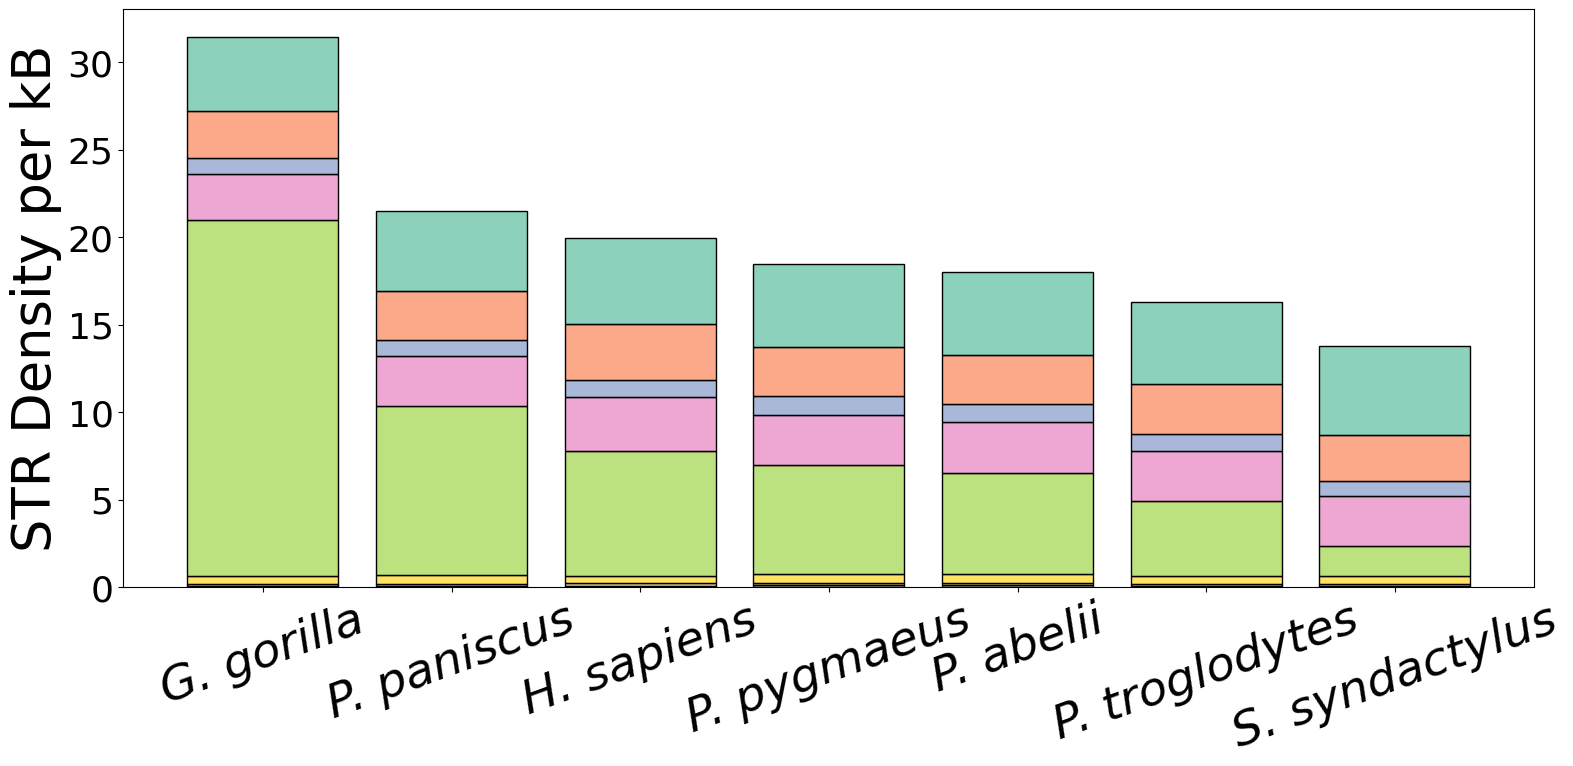

In [28]:
from matplotlib import patches as mpatches
# Alternative approach using seaborn histplot with kind="bar" for stacked bars
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 8))

order=["G. gorilla",
           "P. paniscus",
           "H. sapiens",
           "P. pygmaeus",
           "P. abelii",
           "P. troglodytes",
           "S. syndactylus"]


# STR_motif_perc = STR_motif_perc.sort(by=["species"], descending=False)
STR_motif_perc_pd = merged_STR_total.to_pandas()
STR_motif_perc_pd["species"] = pd.Categorical(
    STR_motif_perc_pd["species"],
    categories=order,
    ordered=True
)
# STR_motif_perc_pd["sru"] = pd.Categorical(
#     STR_motif_perc_pd["sru"],
#     categories=list(range(1, 7)),
#     ordered=True
# )

sns.histplot(
    data=STR_motif_perc_pd, 
    x="species", 
    hue="sru",
    weights="STR_density",
    multiple="stack",
    shrink=0.8,
    ax=ax,
    palette="Set2"
)

plt.xlabel('Species', fontsize=12)
plt.ylabel('STR Density per kB', fontsize=32)
ax.yaxis.label.set_size(38)
ax.tick_params(axis="y", labelsize=26)
ax.tick_params(axis="x", labelsize=34, rotation=20)
ax.yaxis.label.set_size(38)
handles = [mpatches.Patch(color=color, label=f"{sru}") for sru, color in zip(range(1, 7), sns.color_palette("Set2", n_colors=6))]
# ax.legend(title="", handles=handles, fancybox=True, shadow=True, prop={"size": 22}, bbox_to_anchor=(0.88, 1), loc='upper left')
ax.legend(handles=[], frameon=False)
# plt.legend(title='STR Motif (SRU)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax.set_xlabel("")
for label in ax.get_xticklabels():
    label.set_style('italic')
target = Path("../STR_figures/primates_STR").resolve()
target.mkdir(exist_ok=True)
fig.savefig(f"{target}/primates_SRU_motif_breakdown_STR_density_per_mB.pdf", bbox_inches='tight', dpi=300, transparent=True)
plt.show()

## Primate STR Density per Chromosome

In [15]:
def merge_STR_density(species):
    merged_STR = load_merge_sru(species)
    merged_STR_density = merged_STR.group_by(["seqID", "sru"])\
            .agg(
                    total_length=pl.col("length").sum(),
                    species=pl.col("species").first()
            )\
            .join(
        genome_sizes,
        left_on="species",
        right_on="species",
        how="left"
            )\
            .with_columns(
                STR_density=pl.col("total_length") * 1e3 / pl.col("genome_size")
            )\
            .with_columns(
                seqID=pl.col("seqID").map_elements(lambda x: x.split("_")[0])
            )\
            .sort(["seqID", "sru"], descending=[True, True])

    return merged_STR_density

merged_STR_density = merge_STR_density("mSymSyn1")
merged_STR_density

/tmp/ipykernel_13067/516930489.py:17: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


seqID,sru,total_length,species,genome_size,STR_density
str,i64,i64,str,i64,f64
"""chrY""",9,540,"""S. syndactylus""",3262887708,0.000165
"""chrY""",8,2180,"""S. syndactylus""",3262887708,0.000668
"""chrY""",7,4076,"""S. syndactylus""",3262887708,0.001249
"""chrY""",6,43199,"""S. syndactylus""",3262887708,0.013239
"""chrY""",5,583849,"""S. syndactylus""",3262887708,0.178936
…,…,…,…,…,…
"""chr1""",5,137070,"""S. syndactylus""",3262887708,0.042009
"""chr1""",4,480805,"""S. syndactylus""",3262887708,0.147356
"""chr1""",3,144954,"""S. syndactylus""",3262887708,0.044425


In [16]:
total_STR_density_df = merged_STR_df.filter(pl.col("species") == "S. syndactylus").group_by("seqID")\
                .agg(
                    STR_bp=pl.col("length").sum(),
                     species=pl.col("species").first()
                     )\
            .join(
                    genome_sizes.filter(pl.col("species") == "S. syndactylus"),
                    on="species",
                    how="left"
            )\
            .with_columns(
                STR_density=pl.col("STR_bp") * 1e3 / pl.col("genome_size")
            )\
            .with_columns(
                seqID=pl.col("seqID").map_elements(lambda x: x.split("_")[0])
            )\
            .sort("seqID", descending=True)
total_STR_density_df

/tmp/ipykernel_13067/1746333264.py:14: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


seqID,STR_bp,species,genome_size,STR_density
str,i64,str,i64,f64
"""chrY""",957364,"""S. syndactylus""",3262887708,0.29341
"""chrX""",2044258,"""S. syndactylus""",3262887708,0.626518
"""chr9""",2003912,"""S. syndactylus""",3262887708,0.614153
"""chr8""",2227249,"""S. syndactylus""",3262887708,0.682601
"""chr7""",1916011,"""S. syndactylus""",3262887708,0.587213
…,…,…,…,…
"""chr13""",2035447,"""S. syndactylus""",3262887708,0.623818
"""chr12""",1638249,"""S. syndactylus""",3262887708,0.502086
"""chr11""",1813122,"""S. syndactylus""",3262887708,0.55568


In [17]:
merged_STR_density.filter(pl.col("seqID") == "chrM")["STR_density"].sum()

0.0

In [21]:
target

PosixPath('../STR_figures/primates_STR/seqID_sru_density_primates')

/tmp/ipykernel_13067/516930489.py:17: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


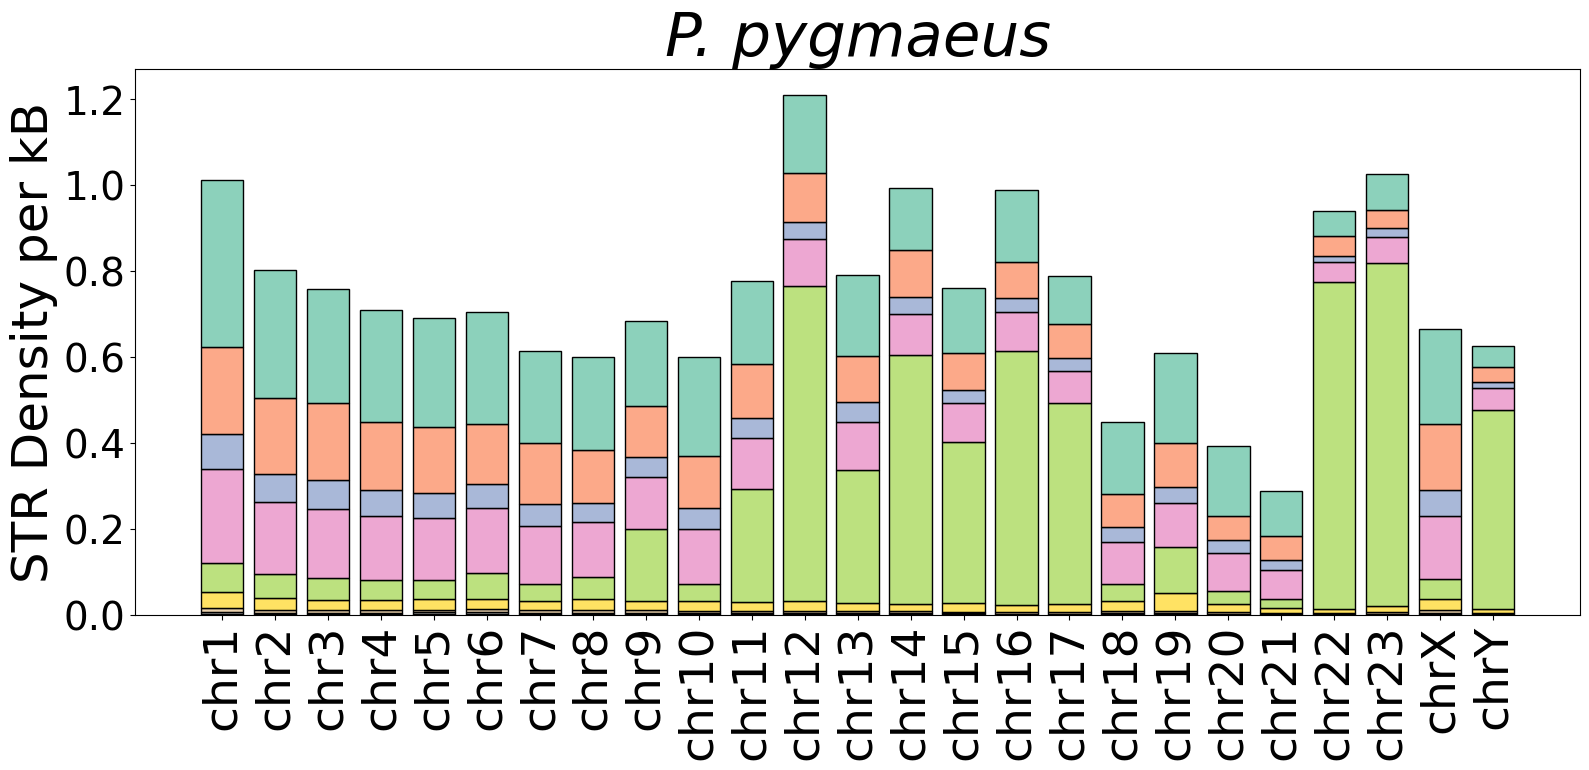

/tmp/ipykernel_13067/516930489.py:17: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


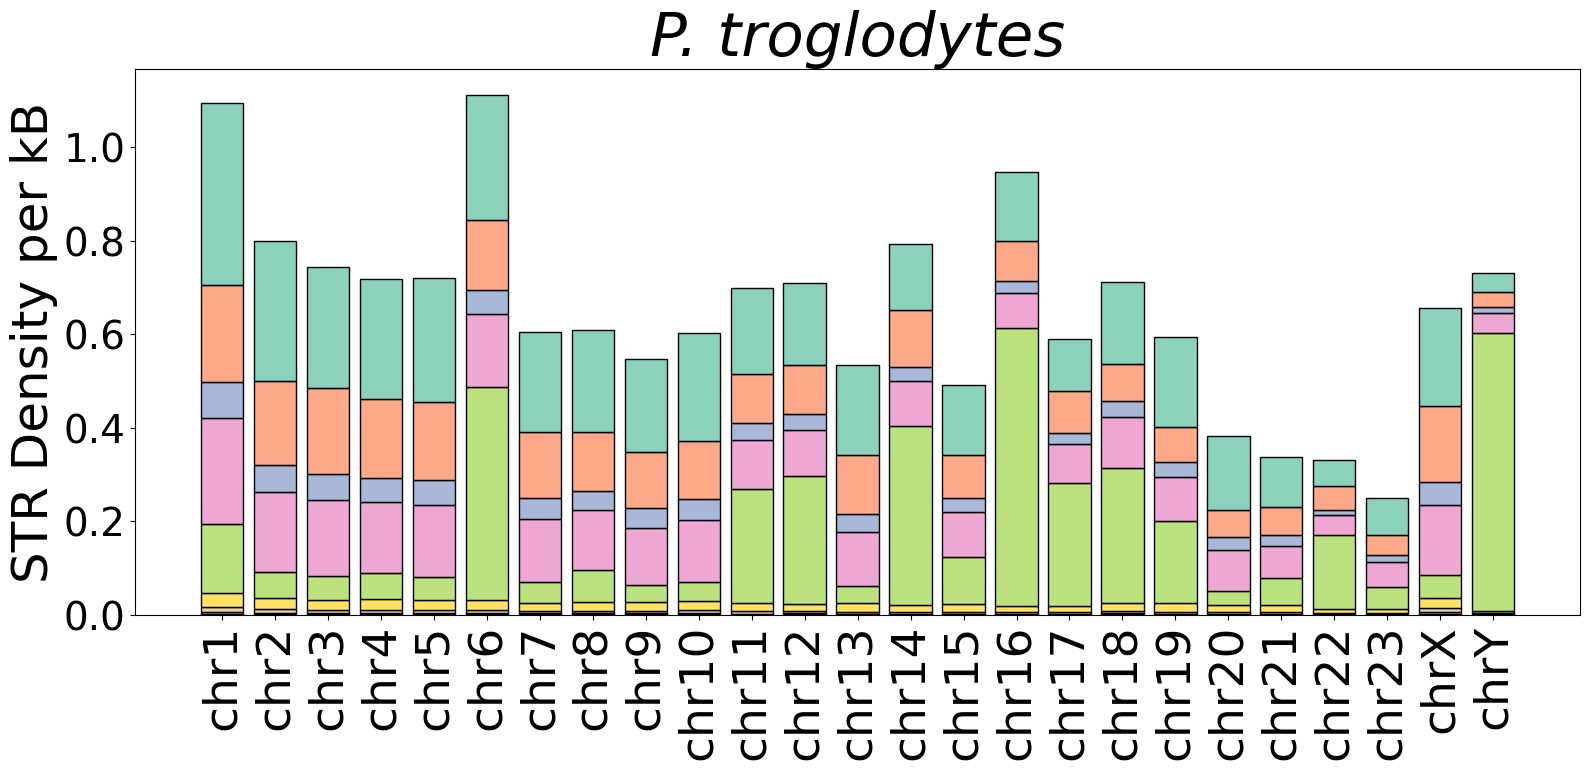

/tmp/ipykernel_13067/516930489.py:17: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


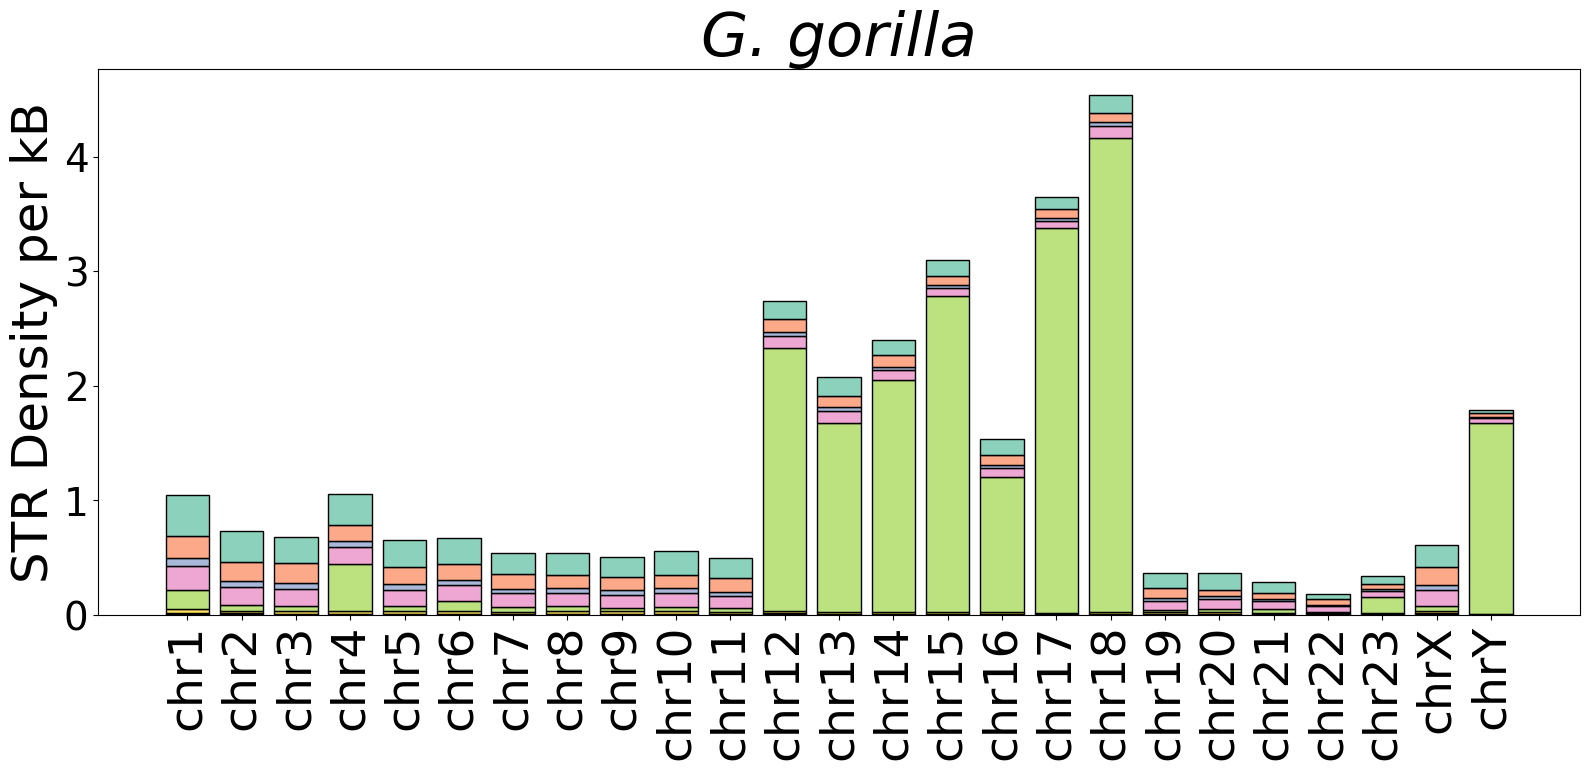

/tmp/ipykernel_13067/516930489.py:17: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


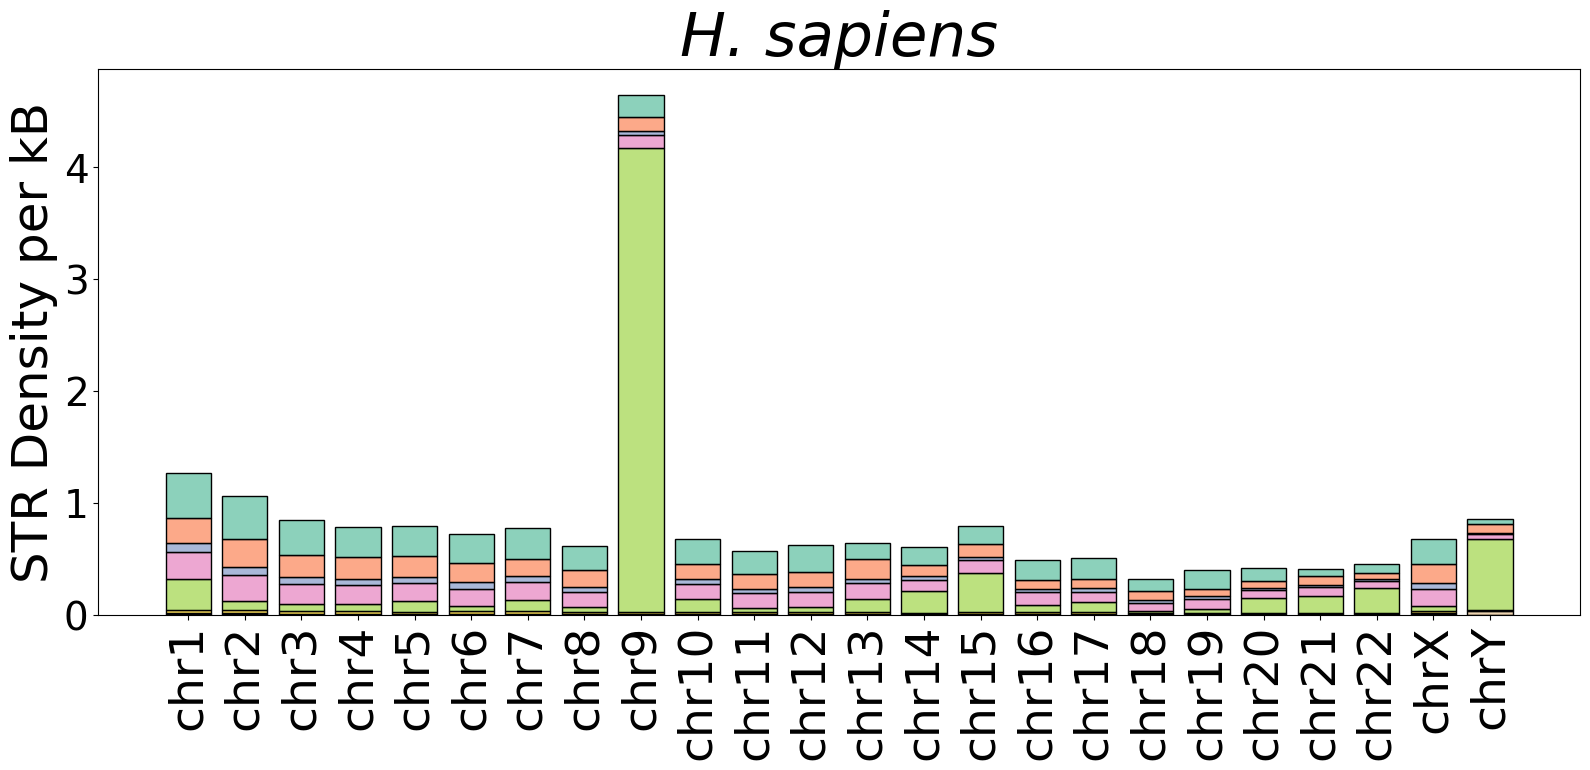

/tmp/ipykernel_13067/516930489.py:17: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


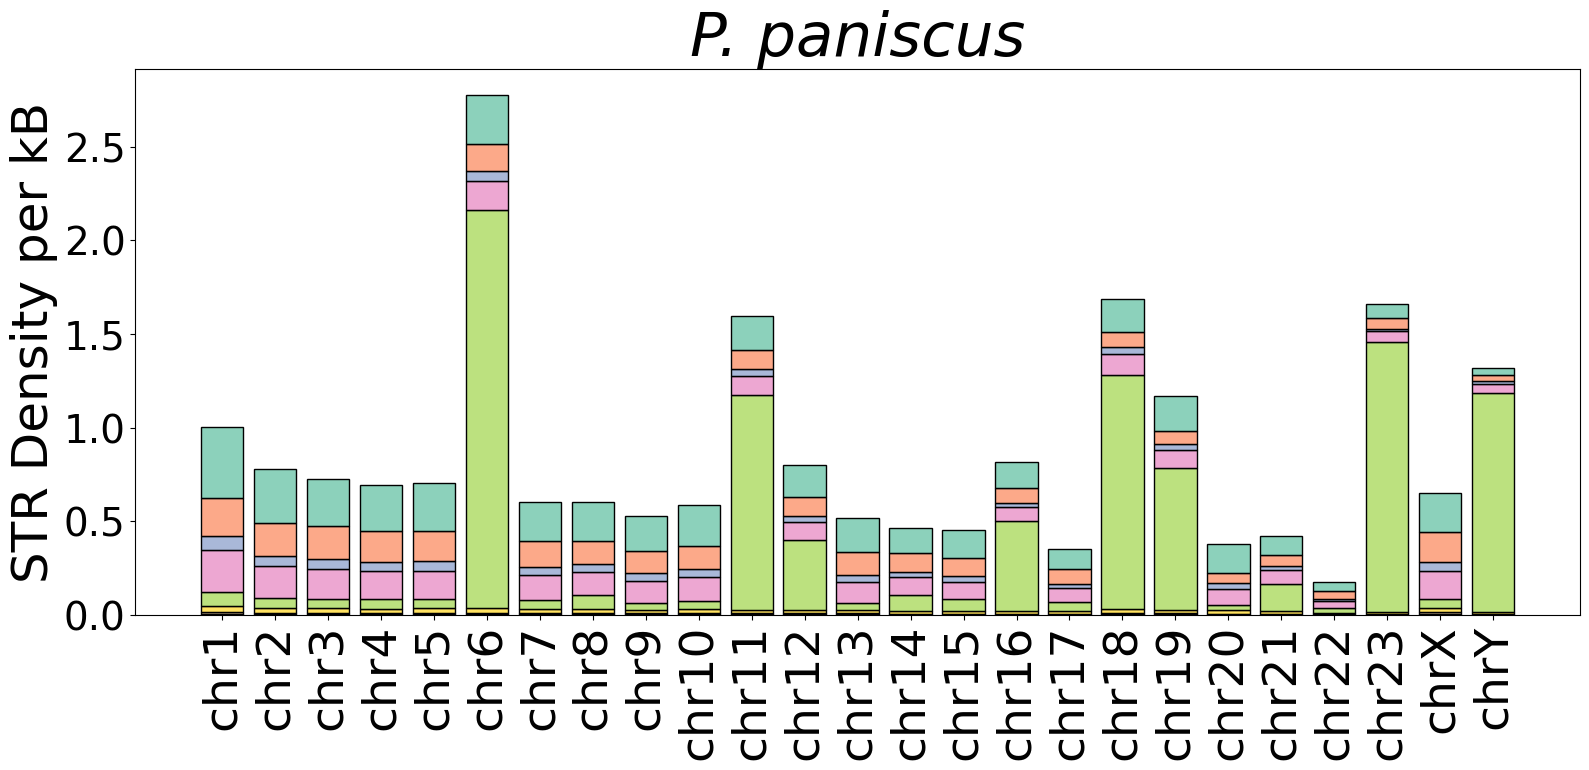

/tmp/ipykernel_13067/516930489.py:17: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


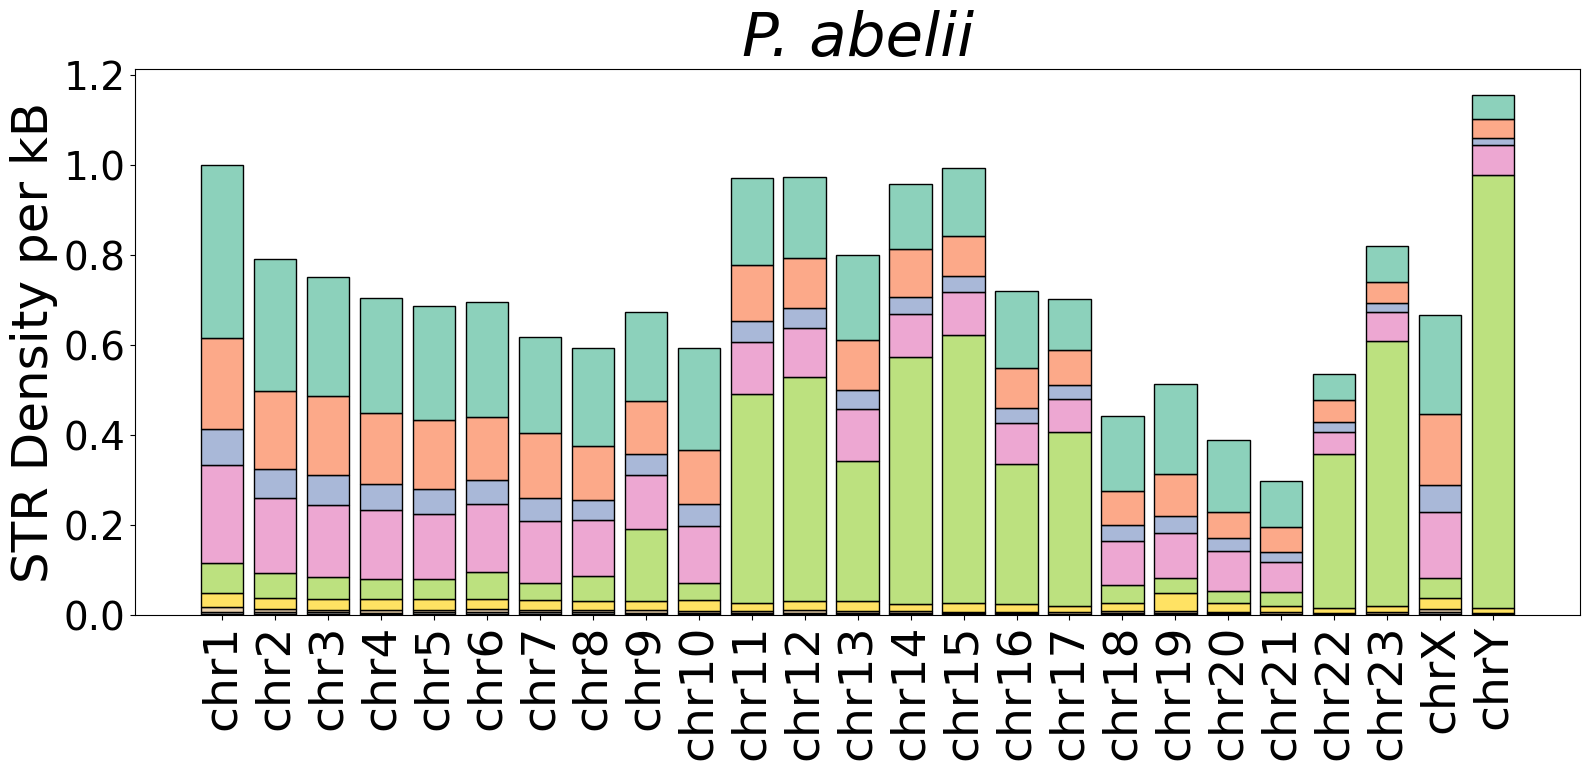

/tmp/ipykernel_13067/516930489.py:17: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


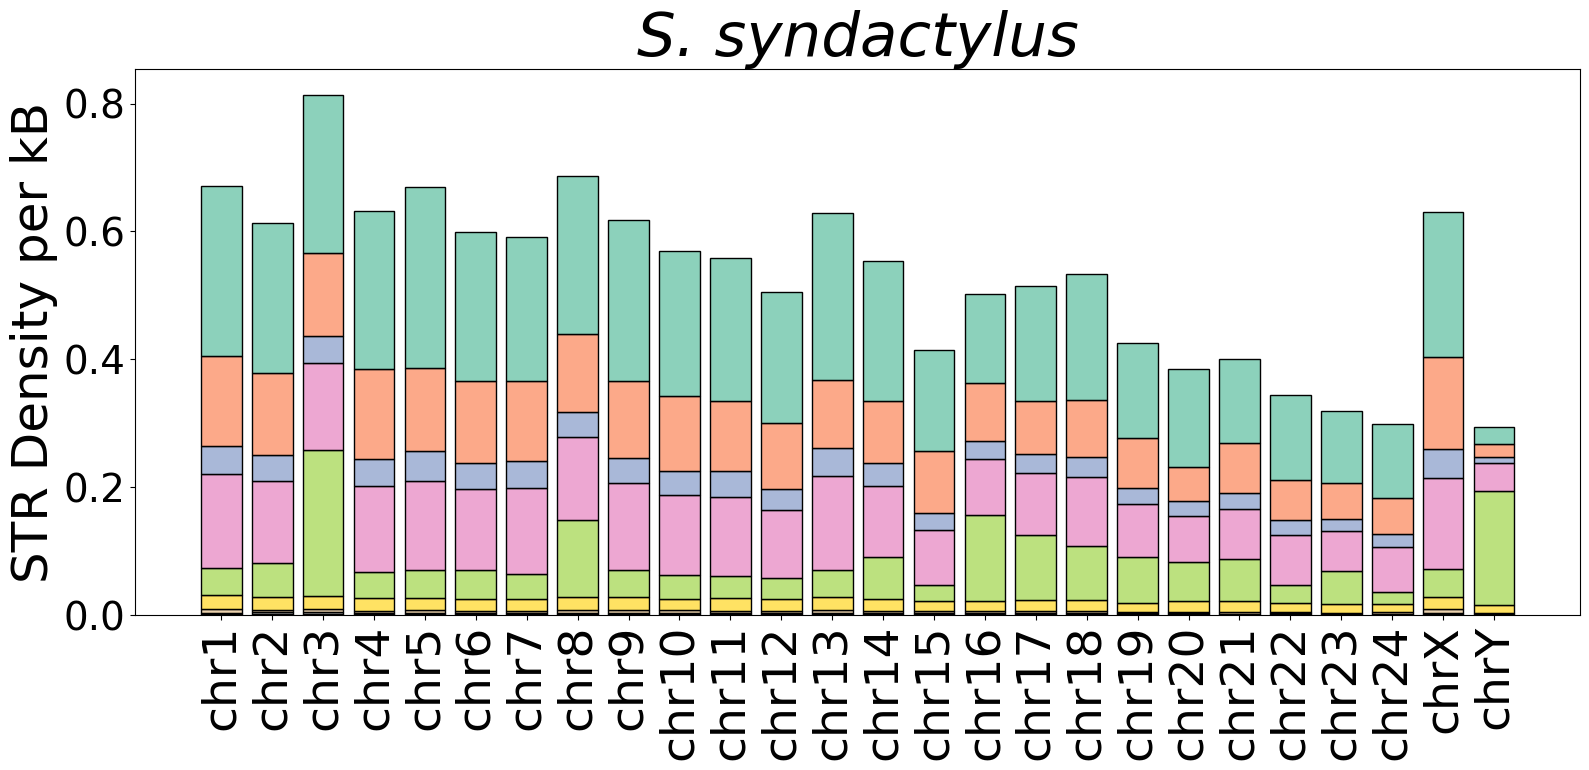

In [22]:
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

target = Path("../STR_figures")
target.mkdir(exist_ok=True)
for species in ["mPonPyg2", "mPanTro3", "mGorGor1", "chm13v2", "mPanPan1", "mPonAbe1", "mSymSyn1"]:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 8))
    merged_STR_density = merge_STR_density(species)
    merged_STR_density = merged_STR_density.filter(pl.col("seqID").map_elements(lambda x: len(x[3:]) <= 2, return_dtype=bool))
    merged_STR_density_pd = merged_STR_density.filter(pl.col("seqID") != "chrM").to_pandas()

    total_sequences = merged_STR_density_pd["seqID"].nunique()
    merged_STR_density_pd["seqID"] = pd.Categorical(
        merged_STR_density_pd["seqID"],
        categories=[f"chr{i}" for i in range(1, total_sequences - 1)] + ["chrX", "chrY"],
        ordered=True
    )
    merged_STR_density_pd.sort_values(by=["seqID", "sru"], ascending=[True, True], inplace=True)

    sns.histplot(
        data=merged_STR_density_pd,
        x="seqID", 
        hue="sru",
        weights="STR_density",
        multiple="stack",
        shrink=0.8,
        ax=ax,
        palette="Set2"
    )
    ax.set_title(primates[species], fontstyle='italic')
    ax.title.set_size(44)
    # fontsize=20)
    # plt.xlabel('Species', fontsize=12)
    ax.set_ylabel('STR Density per kB')
    ax.yaxis.label.set_size(36)
    ax.tick_params(axis="y", labelsize=28)
    ax.tick_params(axis="x", labelsize=34, rotation=90)
#     handles = [mpatches.Patch(color=color, label=f"{sru}") for sru, color in zip(range(1, 7), sns.color_palette("Set2", n_colors=6))]
    ax.legend(title="", handles=[], frameon=False)
    # plt.legend(title='STR Motif (SRU)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    ax.set_xlabel("")
    fig.savefig(f"{target}/primate_STR_density_per_sru_chromosome_{species}.pdf", transparent=True, bbox_inches="tight")
    plt.show()

## Centromeric STR

In [29]:
telomeres = {file.name.split("_")[0].split(".")[0]: file for file in Path("/home/dollzeta/biolab/STR_RTR/primates_ref/telomeres/").glob("*.bed") if file.is_file()}
telomeres

{'mGorGor1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/telomeres/mGorGor1_v2.0.telo.bed'),
 'mPonPyg2': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/telomeres/mPonPyg2_v2.0.telo.bed'),
 'mPonAbe1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/telomeres/mPonAbe1_v2.0.telo.bed'),
 'mSymSyn1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/telomeres/mSymSyn1_v2.0.telo.bed'),
 'mPanPan1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/telomeres/mPanPan1_v2.0.telo.bed'),
 'chm13v2': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/telomeres/chm13v2.0_telomere.bed'),
 'mPanTro3': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/telomeres/mPanTro3_v2.0.telo.bed')}

In [30]:
centromeres = {file.name.split("_")[0].split(".")[0]: file for file in Path("/home/dollzeta/biolab/STR_RTR/primates_ref/centromeres/").glob("*.bed") if file.is_file()}
centromeres

{'mPonAbe1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/centromeres/mPonAbe1_v2.0_CenSat_v2.0.bed'),
 'mPanPan1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/centromeres/mPanPan1_v2.0_CenSat_v2.0.bed'),
 'chm13v2': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/centromeres/chm13v2.0_censat_v2.1.bed'),
 'mGorGor1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/centromeres/mGorGor1_v2.0_CenSat_v2.0.bed'),
 'mPanTro3': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/centromeres/mPanTro3_v2.0_CenSat_v2.0.bed'),
 'mPonPyg2': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/centromeres/mPonPyg2_v2.0_CenSat_v2.0.bed'),
 'mSymSyn1': PosixPath('/home/dollzeta/biolab/STR_RTR/primates_ref/centromeres/mSymSyn1_v2.1_CenSat_v2.0.bed')}

In [31]:
df.head()

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,sru,consensus_repeats,#assembly_accession,species
str,i64,i64,str,i64,str,i64,str,i64,i64,i64,str,str
"""chr1_pat_hsa1""",0,330,"""ctaacc""",6,""".""",0,"""ctaaccctaaccctaaccctaaccctaacc…",330,6,55,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus"""
"""chr1_pat_hsa1""",328,502,"""cctaac""",6,""".""",0,"""cctaaccctaaccctaaccctaaccctaac…",174,6,29,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus"""
"""chr1_pat_hsa1""",506,524,"""aaccct""",6,""".""",0,"""aaccctaaccctaaccct""",18,6,3,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus"""
"""chr1_pat_hsa1""",526,1264,"""cctaac""",6,""".""",0,"""cctaaccctaaccctaaccctaaccctaac…",738,6,123,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus"""
"""chr1_pat_hsa1""",1268,7748,"""aaccct""",6,""".""",0,"""aaccctaaccctaaccctaaccctaaccct…",6480,6,1080,"""mPanPan1.pri.cur.20231122.fast…","""P. paniscus"""


In [32]:
df_censat = pd.read_table(centromeres["mGorGor1"], 
                               header=None,
                               names=["seqID", "start", "end", "compartment"],
                               usecols=range(4)
)
df_censat.loc[:, "compartment"] = df_censat["compartment"].apply(lambda x: x.split("(")[0])
df_censat

,seqID,start,end,compartment
0,chr10_mat_hsa12,9344,319198,subTerm
1,chr10_mat_hsa12,333629,383607,subTerm
2,chr10_mat_hsa12,398037,450448,subTerm
3,chr10_mat_hsa12,464870,681007,subTerm
4,chr10_mat_hsa12,715074,794330,subTerm
...,...,...,...,...
6906,chrY_pat_hsaY,66355886,66474531,HSat1A
6907,chrY_pat_hsaY,66479744,66542478,HSat1A
6908,chrY_pat_hsaY,66547944,66618443,HSat1A
6909,chrY_pat_hsaY,66622329,66937089,HSat1A


In [33]:
df_censat["compartment"].unique()

array(['subTerm', 'gSat', 'cenSat', 'ct', 'mon', 'mon/hor', 'dhor',
       'active_hor', 'bSat', 'HSat3', 'hor', 'rDNA', 'mixedSuperFamily',
       'HSat1B', 'HSat1A', 'HSat2', 'GAP', 'GAP,HSat3', 'HSat2_3'],
      dtype=object)

In [34]:
chm13v2_censat = pd.read_table(centromeres["chm13v2"], 
                               header=None,
                               names=["seqID", "start", "end", "compartment"],
                               usecols=range(4)
)
chm13v2_censat.loc[:, "compartment"] = chm13v2_censat["compartment"].apply(lambda x: x.split("_")[0])
chm13v2_censat

,seqID,start,end,compartment
0,chr1,116796047,121405145,ct
1,chr1,121405145,121406286,censat
2,chr1,121406286,121619169,ct
3,chr1,121619169,121625213,hor
4,chr1,121625213,121667941,hor
...,...,...,...,...
2518,chrY,62025776,62037362,censat
2519,chrY,62052955,62059882,censat
2520,chrY,62061431,62072743,hsat3
2521,chrY,62072743,62087298,bsat


In [35]:
from pybedtools import BedTool 
chm13v2_df = STR_df.filter(pl.col("species") == "H. sapiens")
chm13v2_df_bed = BedTool.from_dataframe(chm13v2_df.to_pandas()).sort()
chm13v2_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,sru,consensus_repeats,#assembly_accession,species
str,i64,i64,str,i64,str,i64,str,i64,i64,i64,str,str
"""chr1""",16,52,"""ccctaa""",6,""".""",0,"""ccctaaccctaaccctaaccctaaccctaa…",36,6,6,"""chm13v2.0.fa""","""H. sapiens"""
"""chr1""",58,172,"""aaccct""",6,""".""",0,"""aaccctaaccctaaccctaaccctaaccct…",114,6,19,"""chm13v2.0.fa""","""H. sapiens"""
"""chr1""",175,283,"""ccctaa""",6,""".""",0,"""ccctaaccctaaccctaaccctaaccctaa…",108,6,18,"""chm13v2.0.fa""","""H. sapiens"""
"""chr1""",286,766,"""aaccct""",6,""".""",0,"""aaccctaaccctaaccctaaccctaaccct…",480,6,80,"""chm13v2.0.fa""","""H. sapiens"""
"""chr1""",771,885,"""ccctaa""",6,""".""",0,"""ccctaaccctaaccctaaccctaaccctaa…",114,6,19,"""chm13v2.0.fa""","""H. sapiens"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chrY""",62456269,62456290,"""gggttag""",7,""".""",0,"""gggttaggggttaggggttag""",21,7,3,"""chm13v2.0.fa""","""H. sapiens"""
"""chrY""",62456284,62456800,"""ggttag""",6,""".""",0,"""ggttagggttagggttagggttagggttag…",516,6,86,"""chm13v2.0.fa""","""H. sapiens"""
"""chrY""",62456800,62460028,"""gggtta""",6,""".""",0,"""gggttagggttagggttagggttagggtta…",3228,6,538,"""chm13v2.0.fa""","""H. sapiens"""


In [36]:
from pybedtools import BedTool 

df = pd.read_table("../compartments_T2T_coding_protein_coding.ZDNA.csv.gz")
df_bed = BedTool.from_dataframe(df).sort()
df

,seqID,start,end,compartment,biotype,comp
0,chr1,0,3000,Telomere,.,Telomere
1,chr1,7505,12982,Exon,non_coding,Non Coding Exons
2,chr1,7505,138480,Gene,non_coding,Non Coding Genes
3,chr1,13444,13584,Exon,non_coding,Non Coding Exons
4,chr1,20891,21087,Exon,non_coding,Non Coding Exons
...,...,...,...,...,...,...
891932,chrY,62451062,62451171,Exon,non_coding,Non Coding Exons
891933,chrY,62451556,62451910,Exon,non_coding,Non Coding Exons
891934,chrY,62451910,62452910,Promoter,non_coding,Non Coding Promoters
891935,chrY,62452320,62453637,censat,.,censat


In [37]:
primates

{'mPonPyg2': 'P. pygmaeus',
 'mPanTro3': 'P. troglodytes',
 'mGorGor1': 'G. gorilla',
 'chm13v2': 'H. sapiens',
 'mPanPan1': 'P. paniscus',
 'mPonAbe1': 'P. abelii',
 'mSymSyn1': 'S. syndactylus'}

In [38]:
from pybedtools import BedTool
from tqdm import tqdm 

def validate_chromosomes(seqID):
    valid_chromosomes = {f"chr{i}" for i in range(1, 30)} 
    valid_chromosomes = valid_chromosomes | {"chrX", "chrY"}
    return any(seqID.startswith(v) for v in valid_chromosomes)
    
STR_primates_cen = []
for file in tqdm(centromeres.values()):
    cen_df = pd.read_table(file, header=None, usecols=range(4), names=["seqID", "start", "end", "compartment"])
    cen_df = cen_df[cen_df["seqID"].apply(lambda x: len(x.split("_")[0][3:]) <= 2)]
    cen_df.loc[:, "compartment"] = cen_df["compartment"].apply(lambda x: x.split("(")[0])
    # cen_df.loc[:, "seqID"] = cen_df["seqID"].apply(lambda x: x.split("_")[0])
    cen_df = cen_df.query("compartment != 'GAP'")
    cen_bed = BedTool.from_dataframe(cen_df).sort()

    species = primates[file.name.split("_")[0].split(".")[0]]
    STR_bed = BedTool.from_dataframe(STR_df.select(["seqID", "start", "end", "sru", "sequence_length", "species"]).filter(pl.col("species") == species).to_pandas().drop_duplicates(subset=["seqID", "start", "end"])).sort()
    STR_centromeres = pd.read_table(
                        STR_bed.intersect(cen_bed, u=True).fn,
                        header=None,
                        names=["seqID", "start", "end", "sru", "sequence_length", "species"]
    )\
    .groupby("sru", as_index=False)\
    .agg(
        totalTandem=("start", "count"),
        length=("sequence_length", "sum"),
        species=("species", "first"),
    )
    total_STR_length = STR_centromeres["length"].sum()
    total_tandem_count = STR_centromeres["totalTandem"].sum()
    STR_centromeres.loc[:, "STR_perc"] = 1e2 * STR_centromeres["length"] / total_STR_length
    STR_centromeres.loc[:, "STR_perc_counts"] = 1e2 * STR_centromeres["totalTandem"] / total_tandem_count
    STR_primates_cen.append(STR_centromeres)
    
STR_primates_cen = pd.concat(STR_primates_cen)
STR_primates_cen

100%|██████████| 7/7 [01:25<00:00, 12.27s/it]


,sru,totalTandem,length,species,STR_perc,STR_perc_counts
0,1,46645,666114,P. abelii,3.540574,4.220824
1,2,42707,628776,P. abelii,3.342113,3.864481
2,3,15189,261402,P. abelii,1.389422,1.374426
3,4,49556,762296,P. abelii,4.051807,4.484235
4,5,943507,16302340,P. abelii,86.651296,85.376286
...,...,...,...,...,...,...
4,5,140501,3056925,S. syndactylus,69.962843,62.749153
5,6,2721,56196,S. syndactylus,1.286139,1.215226
6,7,520,11753,S. syndactylus,0.268987,0.232237
7,8,285,7208,S. syndactylus,0.164967,0.127284


In [46]:
STR_primates_telomeres = []
def validate_chromosome(seqID):
    valid_chromosomes = {f"chr{i}" for i in range(1, 30)} 
    valid_chromosomes = valid_chromosomes | {"chrX", "chrY"}
    return any(seqID.startswith(v) for v in valid_chromosomes)
    
for file in tqdm(telomeres.values()):
    telo_df = pd.read_table(file, header=None, usecols=range(3), names=["seqID", "start", "end"])
    telo_df = telo_df[telo_df["seqID"].apply(lambda x: len(x.split("_")[0][3:]) <= 2)]
    # telo_df.loc[:, "seqID"] = telo_df["seqID"].apply(lambda x: x.split("_")[0])
    telo_bed = BedTool.from_dataframe(telo_df).sort()

    species = primates[file.name.split("_")[0].split(".")[0]]
    # print(file, species)
    STR_bed = BedTool.from_dataframe(STR_df.filter(pl.col("sequence_length") >= 10)
                                           .select(["seqID", "start", "end", "sru", "sequence_length", "species"])
                                           .filter(pl.col("species") == species)
                                           .to_pandas()
                                           .drop_duplicates(subset=["seqID", "start", "end"])).sort()
    STR_telomeres = pd.read_table(
                        STR_bed.intersect(telo_bed, u=True).fn,
                        header=None,
                        names=["seqID", "start", "end", "sru", "sequence_length", "species"]
    )\
    .groupby("sru", as_index=False)\
    .agg(
        totalTandem=("start", "count"),
        length=("sequence_length", "sum"),
        species=("species", "first"),
    )
    total_STR_length = STR_telomeres["length"].sum()
    total_tandem_count = STR_telomeres["totalTandem"].sum()
    STR_telomeres.loc[:, "STR_perc"] = 1e2 * STR_telomeres["length"] / total_STR_length
    STR_telomeres.loc[:, "STR_perc_counts"] = 1e2 * STR_telomeres["totalTandem"] / total_tandem_count
    STR_primates_telomeres.append(STR_telomeres)
    
STR_primates_telomeres = pd.concat(STR_primates_telomeres)
STR_primates_telomeres

100%|██████████| 7/7 [01:19<00:00, 11.31s/it]


,sru,totalTandem,length,species,STR_perc,STR_perc_counts
0,1,8,100,G. gorilla,0.024355,0.649878
1,2,1,14,G. gorilla,0.003410,0.081235
2,3,2,24,G. gorilla,0.005845,0.162470
3,4,4,48,G. gorilla,0.011691,0.324939
4,5,27,435,G. gorilla,0.105945,2.193339
5,6,1144,408816,G. gorilla,99.568181,92.932575
6,7,44,1120,G. gorilla,0.272779,3.574330
7,8,1,32,G. gorilla,0.007794,0.081235
0,1,3,46,P. pygmaeus,0.009258,0.152207
1,3,3,39,P. pygmaeus,0.007850,0.152207


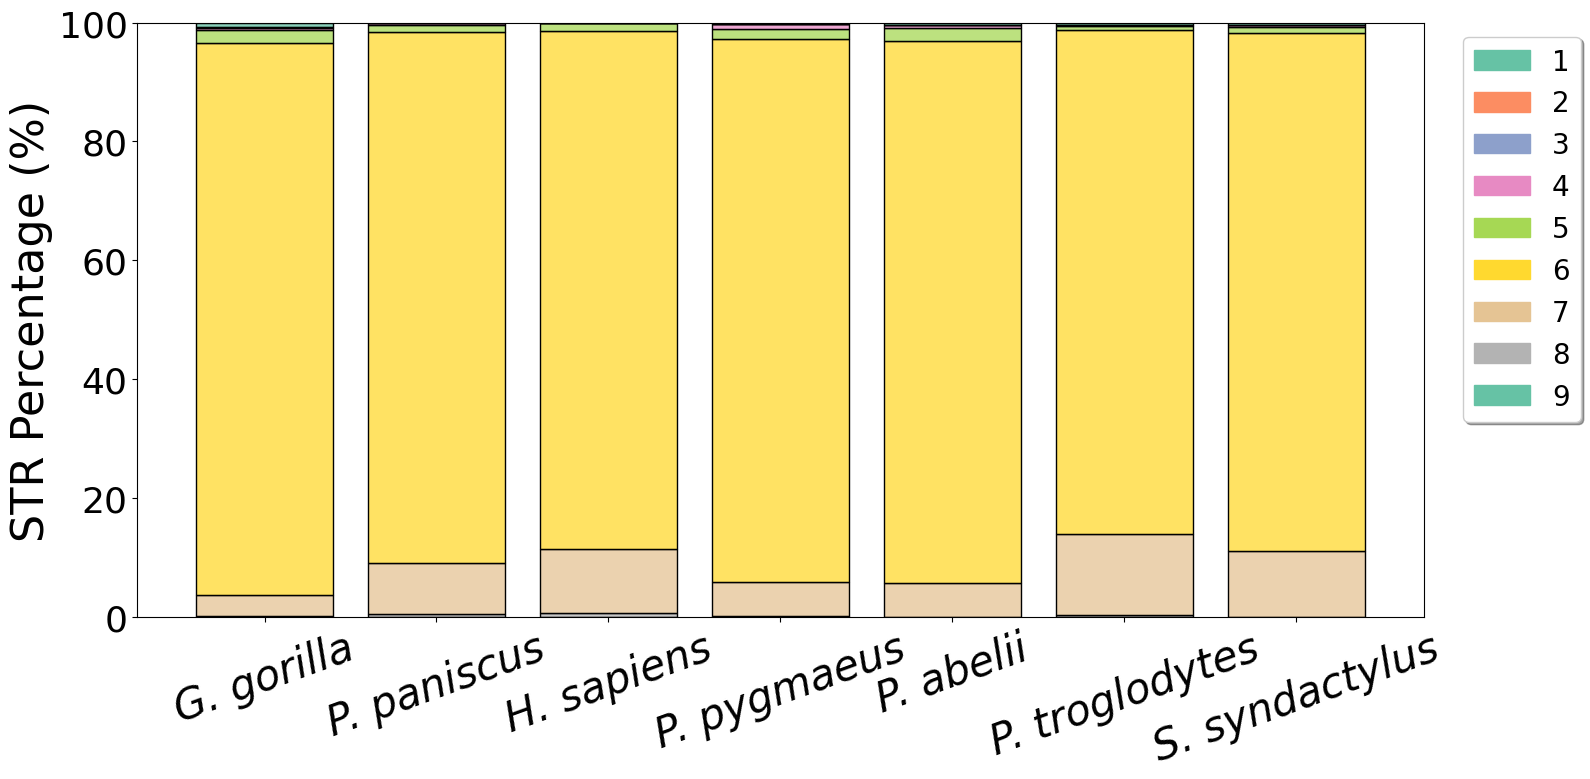

In [47]:
from matplotlib import patches as mpatches
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 8))
order=["G. gorilla",
           "P. paniscus",
           "H. sapiens",
           "P. pygmaeus",
           "P. abelii",
           "P. troglodytes",
           "S. syndactylus"]

# STR_motif_perc = STR_motif_perc.sort(by=["species"], descending=False)
STR_primates_telomeres["species"] = pd.Categorical(
    STR_primates_telomeres["species"],
    categories=order,
    ordered=True
)
STR_primates_telomeres["sru"] = pd.Categorical(
    STR_primates_telomeres["sru"],
    categories=list(range(1, 10)),
    ordered=True
)
sns.histplot(
    data=STR_primates_telomeres, 
    x="species", 
    hue="sru",
    weights="STR_perc_counts",
    multiple="stack",
    shrink=0.8,
    ax=ax,
    palette="Set2"
)

plt.xlabel('Species', fontsize=12)
ax.set_ylabel('STR Percentage (%)')
ax.yaxis.label.set_size(32)
ax.tick_params(axis="y", labelsize=26)
ax.tick_params(axis="x", labelsize=30, rotation=20)
handles = [mpatches.Patch(color=color, label=f"{sru}") for sru, color in zip(range(1, 10), sns.color_palette("Set2", n_colors=9))]
ax.legend(title="", handles=handles, fancybox=True, shadow=True, prop={"size": 20}, bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.legend(title='STR Motif (SRU)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax.set_xlabel("")
ax.set_ylim(ymax=100.0)
for label in ax.get_xticklabels():
    label.set_style('italic')

target = Path("../figures/primate_figures")
target.mkdir(exist_ok=True)

fig.savefig(f"{target}/telomeres_STR_perc_primates.pdf", transparent=True, bbox_inches="tight", dpi=300)
plt.show()

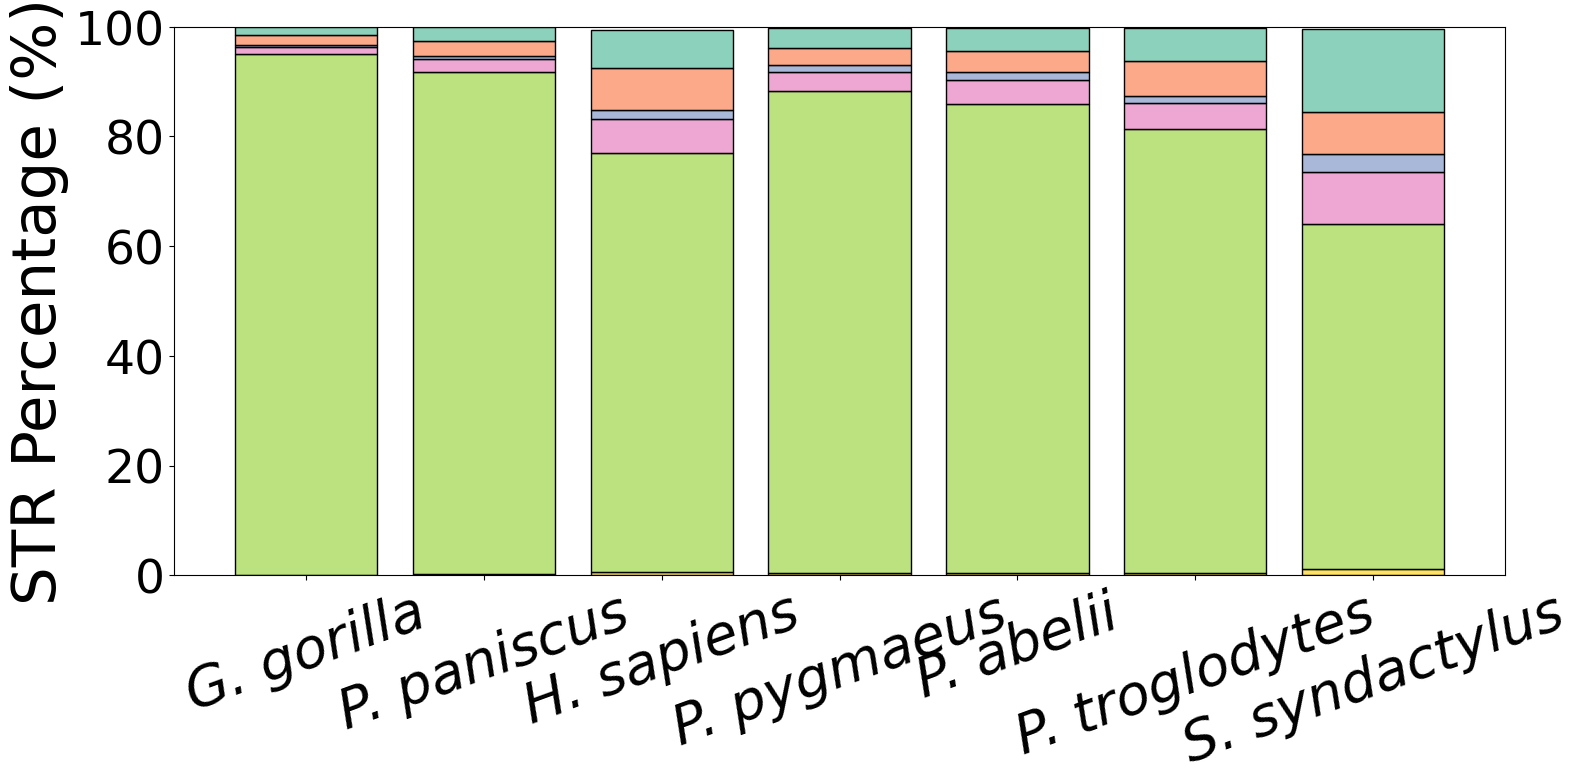

In [55]:
from matplotlib import patches as mpatches

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 8))
order=["G. gorilla",
           "P. paniscus",
           "H. sapiens",
           "P. pygmaeus",
           "P. abelii",
           "P. troglodytes",
           "S. syndactylus"]


STR_primates_cen["species"] = pd.Categorical(
    STR_primates_cen["species"],
    categories=order,
    ordered=True
)
STR_primates_cen["sru"] = pd.Categorical(
    STR_primates_cen["sru"],
    categories=list(range(1, 7)),
    ordered=True
)
sns.histplot(
    data=STR_primates_cen, 
    x="species", 
    hue="sru",
    weights="STR_perc_counts",
    multiple="stack",
    shrink=0.8,
    ax=ax,
    palette="Set2"
)

plt.xlabel('Species', fontsize=12)
plt.ylabel('STR Percentage (%)', fontsize=26)
ax.yaxis.label.set_size(44)
ax.tick_params(axis="y", labelsize=34)
ax.tick_params(axis="x", labelsize=40, rotation=20)
handles = [mpatches.Patch(color=color, label=f"{sru}") for sru, color in zip(range(1, 7), sns.color_palette("Set2", n_colors=6))]
handles = [mpatches.Patch(color=color, label=f"{sru}") for sru, color in zip(range(1, 7), sns.color_palette("Set2", n_colors=6))]
ax.legend(title="", handles=handles, fancybox=True, shadow=True, prop={"size": 20}, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.legend(handles=[], frameon=False)
# plt.legend(title='STR Motif (SRU)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax.set_xlabel("")
ax.set_ylim(ymax=100.0)
for label in ax.get_xticklabels():
    label.set_style('italic')

target = Path("../figures/primate_figures")
target.mkdir(exist_ok=True)
fig.savefig(f"{target}/centromeric_compartments_STR_perc_primates.pdf", transparent=True, bbox_inches="tight", dpi=300)
plt.show()